# Cesarean readiness signal: the complete ML pipeline

**Automated Robson Ten-Group Classification and Cesarean Readiness System: ML workstream**

This notebook walks through the whole modelling workflow, from the raw export to the
interpretation of the selected model:

| § | Step | § | Step |
|---|---|---|---|
| 1 | Data inventory | 8 | Evaluation design |
| 2 | Mapping and data quality | 9 | Training |
| 3 | Robson classification | 10 | Results and comparison |
| 4 | Exploratory data analysis | 11 | Calibration and clinical utility |
| 5 | Leakage audit and feature registry | 12 | Model selection (pre-registered rule) |
| 6 | Populations | 13 | Interpretation |
| 7 | Preprocessing | 14 | Limitations and next steps |

## Purpose

The model estimates **P(cesarean | data available at admission, under current practice)** as an
*operational readiness signal* (for example, expected theatre load) for four Kigali-area
hospitals. It describes what current practice is likely to do. It does **not** estimate clinical
necessity, and no output here is a recommendation for or against a cesarean section.

## Data governance

* The notebook **orchestrates, explains and visualises**. All logic lives in the tested package
  `src/robson_ml`, and the notebook only calls it.
* **Aggregates only.** No record, identifier or individual value is ever displayed. Counts of 1-4 are
  shown as `<5`. Cells hidden to protect another cell are shown as `*`. Histograms merge sparse bins,
  quantiles need at least 5 values on each side, and correlations and calibration bins need a minimum
  number of rows. No plot draws one mark per woman.
* Experiments are read from the local MLflow store (metrics, params and aggregate artefacts). Out-of-fold
  predictions are read only to compute aggregate curves.
* **Commit policy:** the notebook is committed with its outputs cleared
  (`uv run python scripts/strip_notebook.py`). An executed copy on real data belongs under `reports/`,
  which is git-ignored.

## Modes

* `synthetic` (default): builds a synthetic project (raw export, mapping and registry) in a temporary
  directory and runs the whole pipeline end to end, including a small experiment grid. No real data is
  touched.
* `real`: reads `configs/project.yaml`, `data/processed/`, `reports/` and `mlruns/` as already produced by
  the `robson-ml` CLI. No model is trained unless `RUN_LIVE` is set. A live run then goes to a temporary
  MLflow store, never to `mlruns/`.

Set the mode with the environment variable `ROBSON_NOTEBOOK_MODE` (`synthetic` or `real`).

In [1]:
import logging
import os
import platform
import sys
import tempfile
import time
import warnings
from pathlib import Path

MODE = os.environ.get("ROBSON_NOTEBOOK_MODE", "synthetic")
# Real mode only: set to True (or ROBSON_NOTEBOOK_RUN_LIVE=1) to run ONE demonstration
# configuration live. It is tracked in a temporary MLflow store, never in mlruns/.
RUN_LIVE = os.environ.get("ROBSON_NOTEBOOK_RUN_LIVE", "0") == "1"
if MODE not in {"synthetic", "real"}:
    raise ValueError(f"ROBSON_NOTEBOOK_MODE must be 'synthetic' or 'real', not {MODE!r}")

# Synthetic-mode size (never used on real data).
SYNTHETIC_N = int(os.environ.get("ROBSON_NOTEBOOK_SYNTHETIC_N", "1000"))
SYNTHETIC_SEED = 11
SYNTHETIC_TRIALS = 2
SYNTHETIC_BOOT = 50


def find_repo_root(start: Path) -> Path:
    # The first parent holding pyproject.toml and src/robson_ml.
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "robson_ml").exists():
            return candidate
    raise FileNotFoundError("run the notebook from inside the repository")


REPO = find_repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))  # tests.synthetic_project, for synthetic mode

# Library warnings (convergence, deprecations) and MLflow chatter are silenced so that the
# outputs stay readable; none of them carries data.
warnings.filterwarnings("ignore")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
print(f"mode: {MODE}; live training in real mode: {RUN_LIVE}")

mode: real; live training in real mode: False


In [2]:
import json
from importlib.metadata import version

import matplotlib.pyplot as plt
import mlflow  # noqa: F401  (imported first so its logger can be quietened below)
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from typer.testing import CliRunner

import robson_engine
from robson_engine import load_rule_set
from robson_ml import deploy, eda, explain, figures
from robson_ml.cli import app as robson_cli
from robson_ml.cli import load_project_config
from robson_ml.evaluate import (
    ExperimentConfig,
    RunContext,
    comparison_table,
    make_folds,
    run_experiment,
)
from robson_ml.feature_sets import (
    FEATURE_SETS,
    GROUP_ORDER,
    build_model_data,
    deploy_variant,
    feature_spec,
)
from robson_ml.features import build_raw_features, check_coverage, load_feature_registry
from robson_ml.ingest import file_sha256, inventory, read_workbook, select_sheet
from robson_ml.mapping import load_mapping
from robson_ml.metrics import net_benefit
from robson_ml.models import MODEL_REGISTRY, get_model
from robson_ml.populations import POPULATION_VERSION, audit_population, prediction_population
from robson_ml.preregistration import (
    check_preregistration,
    git_commit,
    selection_rule_commit,
)
from robson_ml.privacy import SECONDARY, SUPPRESSED, fmt_count, suppress_table
from robson_ml.profile import published_profile, released_quantiles, status_tables
from robson_ml.robson_run import handcheck_sample, validate_classification
from robson_ml.schema import validate_canonical
from robson_ml.select import (
    experiment_config,
    fold_metrics,
    load_runs,
    load_selection_rule,
    run_artifact_table,
    run_fold_params,
    select_configuration,
)
from robson_ml.splits import recalibration_split

# robson_ml.plots (imported by the harness) selects the Agg backend for MLflow artefacts;
# switch back to inline display.
%matplotlib inline

figures.apply_style()
logging.getLogger("mlflow").setLevel(logging.ERROR)  # after mlflow configured its logger
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
HIDDEN = (SUPPRESSED, SECONDARY)


def show(fig) -> None:
    # Display a figure inline, then release it.
    display(fig)
    plt.close(fig)

### Project setup

In **synthetic** mode a project directory is created and populated exactly as the real one would be,
by running the same CLI commands the project lead runs: `robson-ml ingest`, `robson`, `profile` and
`leakage`. In **real** mode those outputs must already exist.

In [3]:
def run_cli(project: Path, *args: str) -> None:
    # Run one robson-ml command inside the project directory (its paths are relative).
    cwd = os.getcwd()
    os.chdir(project)
    try:
        result = CliRunner().invoke(robson_cli, list(args))
    finally:
        os.chdir(cwd)
    if result.exit_code != 0:
        raise RuntimeError(f"robson-ml {' '.join(args)} failed (details suppressed)")


started = time.time()
if MODE == "synthetic":
    from tests.synthetic_project import build_synthetic_project

    PROJECT = Path(tempfile.mkdtemp(prefix="robson_notebook_"))
    build_synthetic_project(PROJECT, REPO, n=SYNTHETIC_N, seed=SYNTHETIC_SEED)
    for command in ("ingest", "robson", "profile", "leakage"):
        run_cli(PROJECT, command)
    print(f"synthetic project built and processed in {time.time() - started:.0f} s")
else:
    PROJECT = REPO

cfg = load_project_config(PROJECT / "configs" / "project.yaml")


def at(path: Path) -> Path:
    return path if path.is_absolute() else PROJECT / path


RAW_PATH = at(cfg.raw_path)
PROCESSED = at(cfg.processed_dir)
INTERIM = at(cfg.interim_dir)
REPORTS = at(cfg.reports_dir)
CLASSIFIED_PATH = PROCESSED / "canonical_robson.parquet"
OOF_DIR = INTERIM / "oof"
TRACKING_URI = (PROJECT / "mlruns").resolve().as_uri()
SELECTION_RULE_PATH = PROJECT / "configs" / "selection_rule.yaml"
SEED = cfg.seed

required = [
    RAW_PATH,
    PROCESSED / "canonical.parquet",
    CLASSIFIED_PATH,
    INTERIM / "mapping_report.json",
    REPORTS / "leakage" / "leakage_screens.csv",
]
missing = [str(p.relative_to(PROJECT)) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"run the robson-ml CLI first (ingest, robson, profile, leakage); missing: {missing}"
    )

In [4]:
# Everything below is held in memory and never displayed row-wise.
mapping = load_mapping(at(cfg.mapping_path))
sheets = read_workbook(RAW_PATH)
raw = select_sheet(sheets, mapping.sheet).reset_index(drop=True)
canonical = pd.read_parquet(PROCESSED / "canonical.parquet")
classified = pd.read_parquet(CLASSIFIED_PATH)
registry = load_feature_registry(at(cfg.features_path))
raw_features, _ = build_raw_features(raw, registry)
audit, audit_log = audit_population(classified)
FACILITIES = sorted(classified["facility_id"].astype(str).unique())

environment = {
    "executed at": time.strftime("%Y-%m-%d %H:%M"),
    "python": platform.python_version(),
    **{
        lib: version(lib)
        for lib in (
            "numpy",
            "pandas",
            "scikit-learn",
            "xgboost",
            "shap",
            "mlflow",
            "optuna",
            "statsmodels",
        )
    },
    "robson_engine": robson_engine.__version__,
    "rule set": load_rule_set().version_label,
    "git commit": git_commit(REPO),
    "selection rule commit": selection_rule_commit(REPO),
    "population version": POPULATION_VERSION,
    "raw export sha256": file_sha256(RAW_PATH),
    "processed data sha256 (data_hash)": file_sha256(CLASSIFIED_PATH),
    "feature registry sha256": registry.sha256,
}
pd.DataFrame({"value": environment}).rename_axis("item")

,value
item,
executed at,2026-09-26 20:52
python,3.11.0
numpy,2.4.6
pandas,2.3.3
scikit-learn,1.9.1
xgboost,3.2.0
shap,0.51.0
mlflow,3.16.1
optuna,5.0.0


## 1. Data inventory

What the raw export contains: its sheets, their size and the kind of each column, as inferred from its
values (`ingest.infer_kind`). Only column names and counts are shown, never cell values. Record counts go
through `fmt_count`, and column completeness is shown as a distribution over columns.

In [5]:
inv = inventory(sheets)
sheet_rows = []
for i, sheet in enumerate(inv["sheets"], start=1):
    kinds = pd.Series([c["kind"] for c in sheet["columns"]]).value_counts()
    sheet_rows.append(
        {
            "sheet": f"sheet {i}",
            "rows": fmt_count(sheet["n_rows"]),
            "columns": sheet["n_cols"],
            "form versions": len(sheet.get("versions", {})),
            **{f"{kind} columns": int(n) for kind, n in kinds.items()},
        }
    )
pd.DataFrame(sheet_rows).fillna(0)

,sheet,rows,columns,form versions,categorical columns,empty columns,numeric columns,text columns,datetime columns
0,sheet 1,5520,160,0,82,36,33,8,1


In [6]:
main = next(s for s in inv["sheets"] if s["n_rows"] == len(raw) and s["n_cols"] == raw.shape[1])
columns = pd.DataFrame(main["columns"])
columns["pct_complete"] = 100.0 * columns["n_nonnull"] / max(main["n_rows"], 1)
bands = pd.cut(
    columns["pct_complete"],
    bins=[-0.1, 0, 10, 50, 90, 99.9, 100],
    labels=["empty", "(0, 10]", "(10, 50]", "(50, 90]", "(90, 100)", "complete"],
)
completeness = pd.crosstab(bands, columns["kind"]).rename_axis(index="% complete", columns="kind")
display(completeness)
empty_columns = columns.loc[columns["kind"] == "empty", "name"].tolist()
print(f"empty columns ({len(empty_columns)}): {empty_columns}")

kind,categorical,datetime,empty,numeric,text
% complete,,,,,
empty,0,0,36,0,0
"(0, 10]",6,0,0,11,1
"(10, 50]",8,0,0,4,2
"(50, 90]",4,0,0,2,1
"(90, 100)",0,0,0,2,0
complete,64,1,0,14,4


empty columns (36): ['Hospital Name.1', 'start', 'Patient UPI.1', 'end', 'Date of Delivery.1', 'Maternal DOB', 'Maternal Age', 'Maternal Age in Years', 'Maternal Height.1', 'Maternal Height in cm', 'Maternal Weight.1', 'Maternal Weight in kg ', 'Education Level.1', 'Residency.1', 'numbers!', 'Sector.1', 'District.1', 'Transferring Health Center.1', 'Health Insurance Type.1', 'Marital Status.1', 'Indication of induction .1', 'Maternal request', 'PROM (premature Rupture Of the Membrane)  ', 'Maternal Request .1', 'Uterus Rupture ', 'Additional Uterotonic ', 'Previous PPH', 'Ongoing Medication ', 'Anemia ', 'If yes, specify', 'Birth Interval less than 2 years ', 'Epidural', 'Previous Still Birth ', 'APGAR >= 7', 'APGAR<7', 'Reason for Newborn Admission into NICU.1']


## 2. Mapping and data quality

`configs/mapping_ur_cmhs.yaml` maps raw columns to the canonical admission schema (spec §5). Ambiguous
mappings are flagged for review and never guessed. For each field, the raw non-missing values split into
*mapped*, *explicit missing* (a recorded "unknown"), *unparsed*, *out of range* and *incomplete*. Because
these parts add up to a count that is published elsewhere, any part holding 1-4 is protected against
subtraction as well.

In [7]:
report = json.loads((INTERIM / "mapping_report.json").read_text(encoding="utf-8"))
parts = ["n_mapped", "n_explicit_missing", "n_unparsed", "n_out_of_range", "n_incomplete"]
fields = pd.DataFrame(report["fields"])
fields["unmapped levels"] = fields["unmapped_levels"].map(len)
mapping_table = eda.suppress_partition(
    fields[["canonical", "kind", "status", *parts, "unmapped levels"]], parts
)
display(mapping_table.set_index("canonical"))
print(f"canonical fields with no mapping: {report['missing_canonical_fields']}")
print(f"fields flagged for review: {report['review_fields']}")
print(f"raw columns not used by the mapping: {len(report['unreferenced_raw_columns'])}")

,kind,status,n_mapped,n_explicit_missing,n_unparsed,n_out_of_range,n_incomplete,unmapped levels
canonical,,,,,,,,
admission_id,row_key,confirmed,5520,0,0,0,0,0
mother_key,hash_key,confirmed,5520,0,0,0,0,0
facility_id,text,confirmed,5520,0,0,0,0,0
delivery_date,datetime,confirmed,5520,0,0,0,0,0
parity,integer_sum,review,5517,0,<5,0,<5,0
previous_cs_count,category,confirmed,*,0,<5,0,0,1
fetal_presentation,category,review,5520,0,0,0,0,0
plurality,category,review,5520,0,0,0,0,0
gestational_age_weeks,gestational_age,confirmed,3597,0,34,16,0,0


canonical fields with no mapping: ['recorded_indication']
fields flagged for review: ['parity', 'fetal_presentation', 'plurality', 'ga_band_lower', 'ga_band_upper', 'onset_of_labour', 'prelabour_cs_type', 'anc_contacts']
raw columns not used by the mapping: 142


In [8]:
# Schema validation (pandera); errors would be re-raised with counts only.
try:
    validate_canonical(canonical)
    print("canonical schema: valid (spec 5: types, levels and plausible ranges)")
except Exception as error:
    print(f"canonical schema: INVALID ({type(error).__name__}; see the CLI in a private session)")

canonical schema: valid (spec 5: types, levels and plausible ranges)


## 3. Robson classification

The `robson_engine` package (shared with the application) classifies every record from the six Robson
inputs. A condition over a missing input is *unknown*. A record is **resolved** when exactly one group is
admissible with all of its conditions true, **partial** when several groups remain, and **conflict** when
none does. Coarse inputs, such as presentation recorded only as "non-cephalic" or gestational age known
only as a band, can leave a record partial.

The status, resolving-field and Robson report tables below are the same jointly suppressed tables
published in `reports/profile/robson_inputs.md`, so the notebook cannot be differenced against the
report.

In [9]:
status, resolving, report_table = status_tables(classified)
display(status.set_index("status"))
check = validate_classification(classified)
print(
    f"records: {fmt_count(check.n_total)}; complete precise inputs: "
    f"{fmt_count(check.n_complete_inputs)}; records with a coarse input: "
    f"{fmt_count(check.n_coarse_inputs)}; resolved with >1 candidate: "
    f"{check.n_multi_group_resolved}; counts reconcile: {check.reconciles}"
)
print(
    "hand-check list (spec 6.5; reviewed by hand, never shown here): "
    f"{fmt_count(len(handcheck_sample(classified, SEED)))} records"
)
display(Markdown("**Partial records: fields that would resolve them**"))
resolving.set_index("resolving_fields")

,n,pct
status,,
resolved,5213,94.4
partial,307,5.6
conflict,0,0.0


records: 5520; complete precise inputs: 3499; records with a coarse input: 2019; resolved with >1 candidate: 0; counts reconcile: True
hand-check list (spec 6.5; reviewed by hand, never shown here): 153 records


**Partial records: fields that would resolve them**

,n
resolving_fields,
fetal_presentation,153
gestational_age_weeks,151
parity;previous_cs_count,<5
parity,<5


,n,pct_of_deliveries,n_cs,cs_rate,abs_contribution,rel_contribution
row,,,,,,
1,1269,0.23,238,0.187549,0.04,0.10
2,435,0.08,276,0.634483,0.05,0.11
3,1549,0.28,145,0.093609,0.03,0.06
4,357,0.06,154,0.431373,0.03,0.06
5,1334,0.24,1283,0.961769,0.23,0.53
6,0,0.00,0,NaN,0.00,0.00
7,0,0.00,0,NaN,0.00,0.00
8,28,0.01,<5,<5,<5,<5
9,0,0.00,0,NaN,0.00,0.00


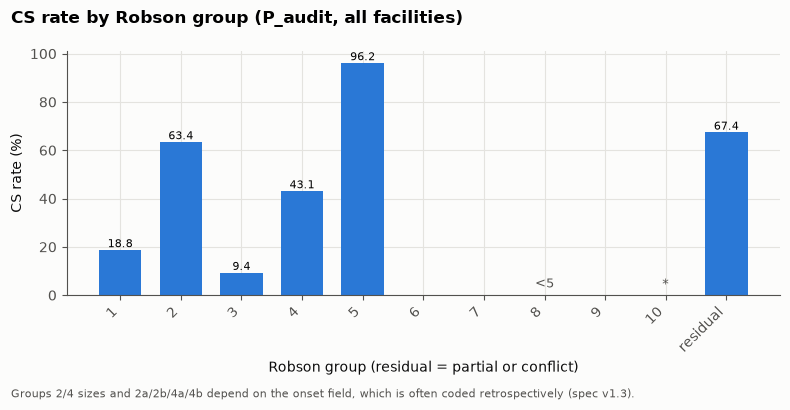

In [10]:
overall = report_table[report_table["facility"] == "ALL"].set_index("row")
display(overall.drop(columns="facility"))
show(
    figures.bar_chart(
        overall.index.tolist(),
        [v if isinstance(v, str) else 100 * float(v) for v in overall["cs_rate"]],
        "CS rate by Robson group (P_audit, all facilities)",
        "Robson group (residual = partial or conflict)",
        "CS rate (%)",
        note="Groups 2/4 sizes and 2a/2b/4a/4b depend on the onset field, which is often "
        "coded retrospectively (spec v1.3).",
    )
)

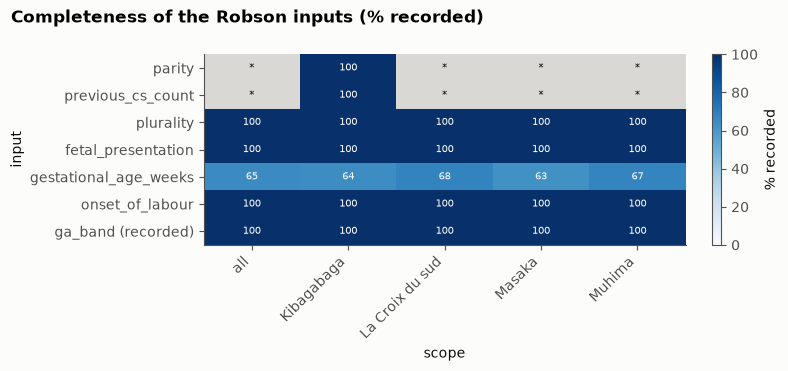

In [11]:
# Completeness of the six inputs, overall and per facility (% recorded), linked to the
# variable profile's missingness so that no file fills in what another hides.
profile_table, canonical_counts = published_profile(raw, classified, mapping)
completeness = canonical_counts.completeness.set_index("input")
show(
    figures.heatmap(
        completeness,
        "Completeness of the Robson inputs (% recorded)",
        "scope",
        "input",
        "% recorded",
        vmin=0,
        vmax=100,
    )
)

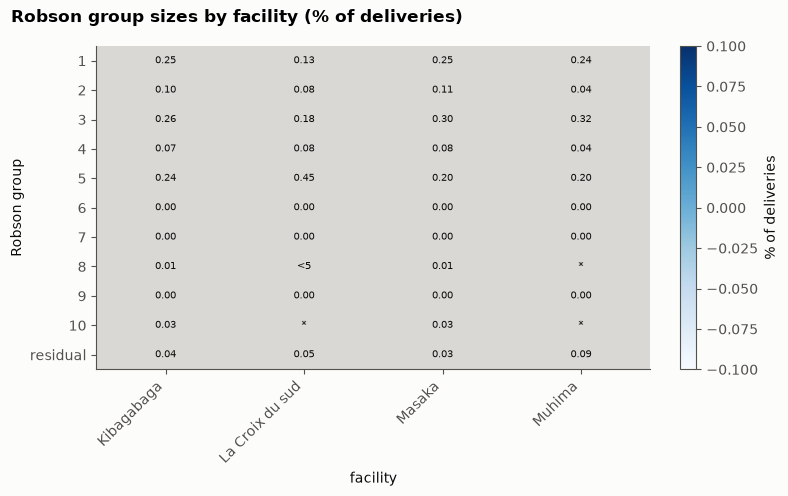

In [12]:
by_facility = report_table[report_table["facility"] != "ALL"]
size_matrix = by_facility.pivot(index="row", columns="facility", values="pct_of_deliveries")
size_matrix = size_matrix.reindex(overall.index).map(
    lambda v: v if isinstance(v, str) else 100 * float(v)
)
show(
    figures.heatmap(
        size_matrix,
        "Robson group sizes by facility (% of deliveries)",
        "facility",
        "Robson group",
        "% of deliveries",
        fmt="{:.1f}",
    )
)

## 4. Exploratory data analysis (aggregate)

Outcome rates are described on **P_audit** (every record with a known mode of delivery). Predictors are
described on **P_pred** (spec v1.3), the population the readiness model is trained on (§6). Every table
comes from `robson_ml.eda`, which suppresses small cells and merges sparse histogram bins.

### 4.1 Outcome: CS rate by facility and over time

,n,n_outcome,rate_pct
facility_id,,,
Kibagabaga,1325,563,42.5
La Croix du sud,743,478,64.3
Masaka,1665,585,35.1
Muhima,1787,777,43.5


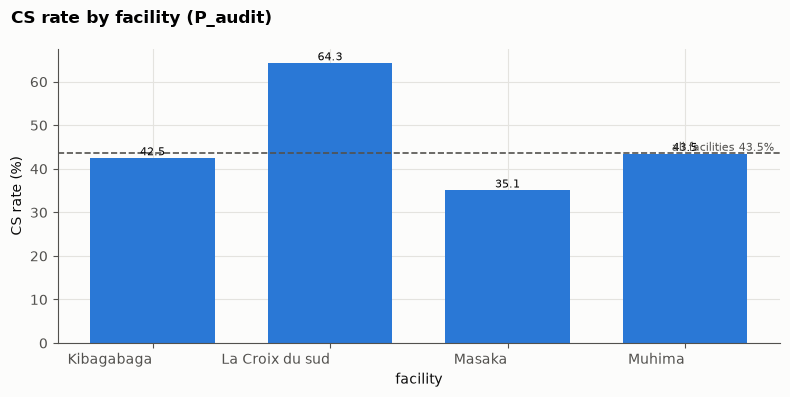

In [13]:
rates = eda.rate_by(audit, "facility_id")
display(rates.set_index("facility_id"))
overall_rate = 100.0 * float(audit["cs"].mean())
show(
    figures.bar_chart(
        rates["facility_id"].tolist(),
        rates["rate_pct"].tolist(),
        "CS rate by facility (P_audit)",
        "facility",
        "CS rate (%)",
        reference=overall_rate,
        reference_label=f"all facilities {overall_rate:.1f}%",
    )
)

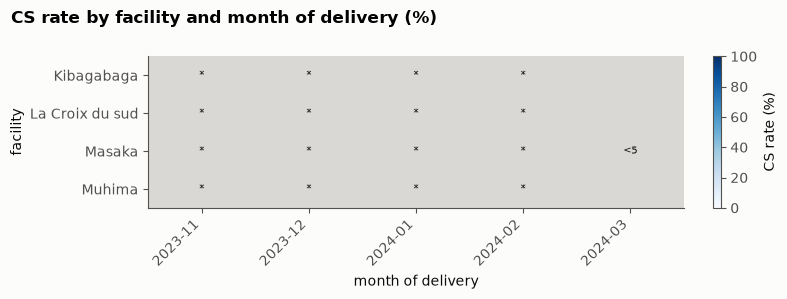

In [14]:
audit_month = audit.assign(month=audit["delivery_date"].dt.to_period("M").astype(str))
cross = eda.rate_by(audit_month, ["facility_id", "month"])
rate_matrix = cross.pivot(index="facility_id", columns="month", values="rate_pct")
show(
    figures.heatmap(
        rate_matrix,
        "CS rate by facility and month of delivery (%)",
        "month of delivery",
        "facility",
        "CS rate (%)",
        vmin=0,
        vmax=100,
    )
)

### 4.2 Model population and numeric predictors

The model inputs are built by `feature_sets.build_model_data`, which uses only the `status: include`
features of the registry (§5). Histograms use fixed domain grids, or edges derived from released
percentiles, and show each outcome group as a percentage of its own total, so that the shapes can be
compared.

In [15]:
data = build_model_data(classified, registry, raw_features, "P_pred")
fs4 = feature_spec(data, "FS4")
x4 = data.x[list(fs4.columns)]
outcome = pd.Series(np.where(data.y == 1, "CS", "vaginal"), index=x4.index)
missingness = eda.missingness_matrix(x4, list(fs4.columns), data.meta["facility_id"])
summary = pd.DataFrame(
    {
        column: {
            "% missing": missingness.loc[column, "all"],
            **released_quantiles(x4[column].dropna().astype(float)),
        }
        for column in fs4.numeric
    }
).T
summary.rename_axis("numeric feature (P_pred)").round(2)

,% missing,p5,p25,p50,p75,p95
numeric feature (P_pred),,,,,,
gestational_age_weeks,34.0,36.0,38.571429,39.285714,40.0,41.285714
ga_band_lower,0.0,35.0,38.0,38.0,38.0,40.142857
ga_band_upper,0.0,37.857143,40.857143,40.857143,40.857143,45.0
parity,<5,0.0,0.0,1.0,2.0,4.0
previous_cs_count,<5,0.0,0.0,0.0,0.0,1.0
plurality,0.0,1.0,1.0,1.0,1.0,1.0
maternal_age,<5,18.1,23.0,28.0,33.0,40.0
height_cm,*,154.0,159.0,162.0,165.0,168.0
weight_kg,0.0,55.0,60.0,66.0,72.0,87.0


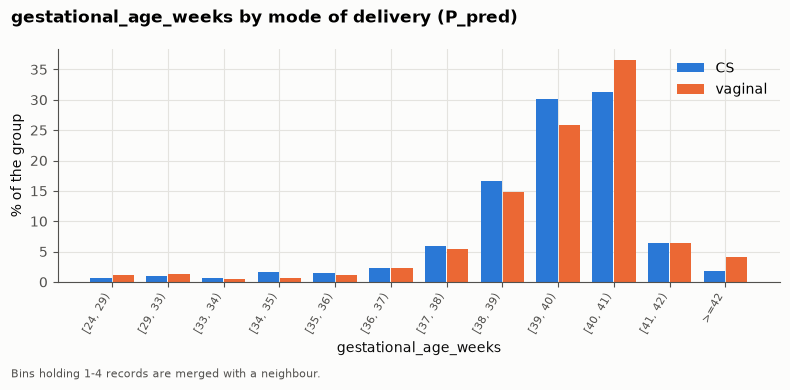

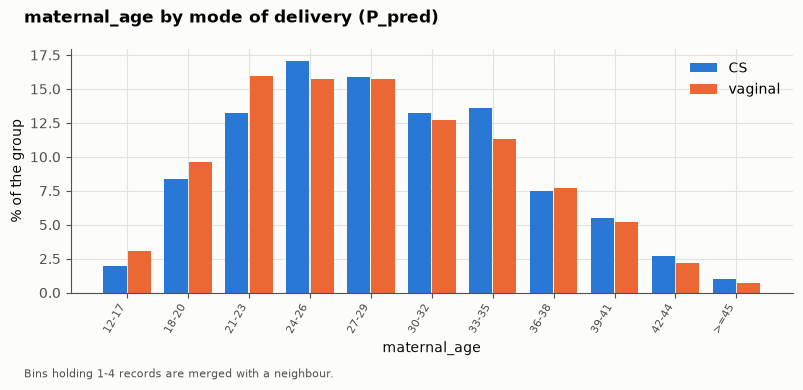

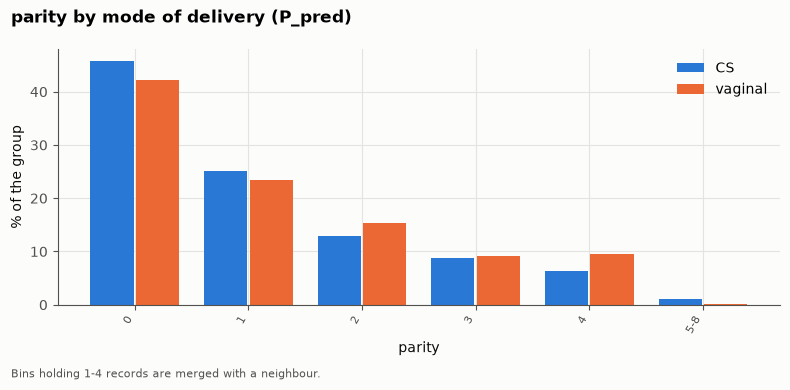

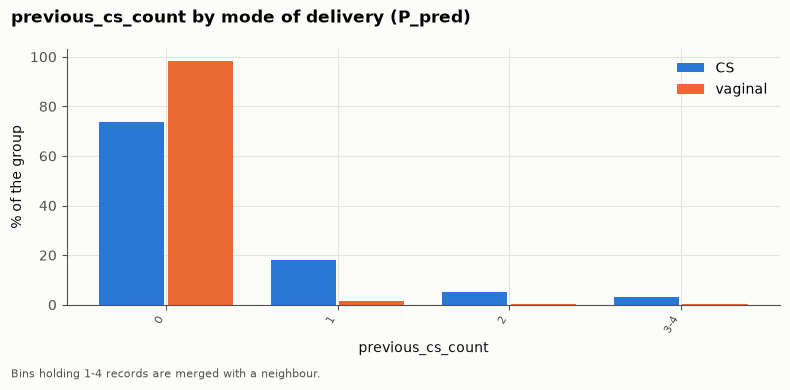

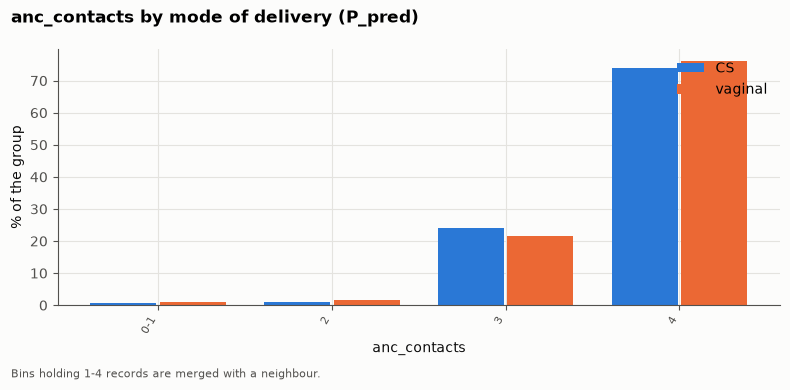

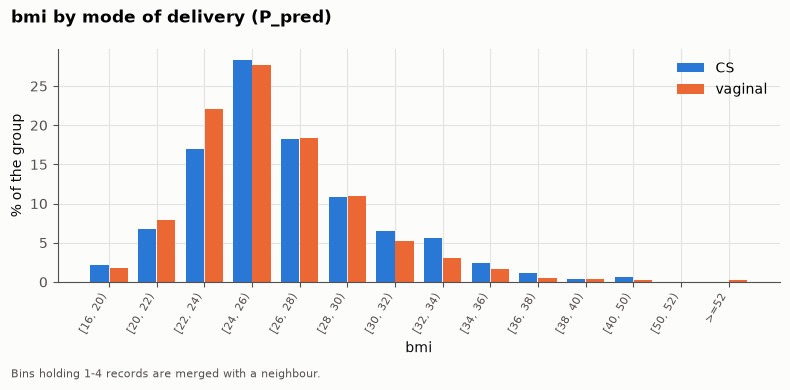

In [16]:
KEY_NUMERIC = [
    c
    for c in (
        "gestational_age_weeks",
        "maternal_age",
        "parity",
        "previous_cs_count",
        "anc_contacts",
        "bmi",
    )
    if c in x4.columns
]
for column in KEY_NUMERIC:
    table = eda.binned_hist_counts(x4[column], by=outcome, name=column)
    if table.empty:
        print(f"{column}: too few values to show a histogram")
        continue
    show(
        figures.histogram(
            table,
            ["CS", "vaginal"],
            f"{column} by mode of delivery (P_pred)",
            column,
        )
    )

### 4.3 Categorical predictors: level counts and CS rates (rare levels pooled)

In [17]:
categorical_tables = []
for column in fs4.categorical:
    table = eda.level_rates(x4[column], pd.Series(data.y, index=x4.index))
    table.insert(0, "feature", column)
    categorical_tables.append(table)
categorical_summary = pd.concat(categorical_tables, ignore_index=True)
categorical_summary.set_index(["feature", "level"])

n n_outcome  \
feature               level                                               
fetal_presentation    cephalic                           4141      1052   
                      non_cephalic                        124       113   
robson_group_no_onset 10                                  214        50   
                      1_2                                1631       445   
                      3_4                                1851       252   
                      5                                   304         *   
                      8                                    15        <5   
                      partial                             250       151   
education_level       (rare)                               <5        <5   
                      Complete Primary school             749       242   
                      Completed secondary school         1025       234   
                      Did not complete primary school     979       272   
                      Did not complete secondary school  1152       274   
                      Did not go to school                  *         *   
                      University education or more        268        98   
residency             Rural                              1079       320   
                      Urban                              3186       845   
insurance_type        Mutuel                             3783       997   
                      None                                 48        18   
                      Others                              195        66   
                      RSSB                                239        84   
marital_status        Cohabitant                          488         *   
                      Divorced                              5        <5   
                      Married                            2354       673   
                      Never Married                      1418       338   
occupation            Full Time Job                       572       218   
                      N/A                                   8         0   
                      Not Working                        1475       318   
                      Part Time Job                      2210       629   
living_children_band  (missing)                          1623       483   
                      0                                    12        <5   
                      4 or more                           629         *   
                      Less than 4                        2001       517   
previous_stillbirth   No                                 4241      1156   
                      Yes                                  24         9   
preeclampsia_recorded (missing)                            <5        <5   
                      no                                 4220      1138   
                      yes                                   *         *   
hiv_positive          (missing)                            <5        <5   
                      No                                 4204      1151   
                      Yes                                   *         *   
ivf                   No                                 4260         *   
                      Yes                                   5        <5   
antenatal_admission   No                                 4220      1146   
                      Yes                                  45        19   
gdm_recorded          (rare)                               <5        <5   
                      no                                    *         *   
malaria_in_pregnancy  No                                 4253      1159   
                      Yes                                  12         6   
gu_infection          No                                 4234      1151   
                      Yes                                  31        14   

                                                        rate_pct  
feature          

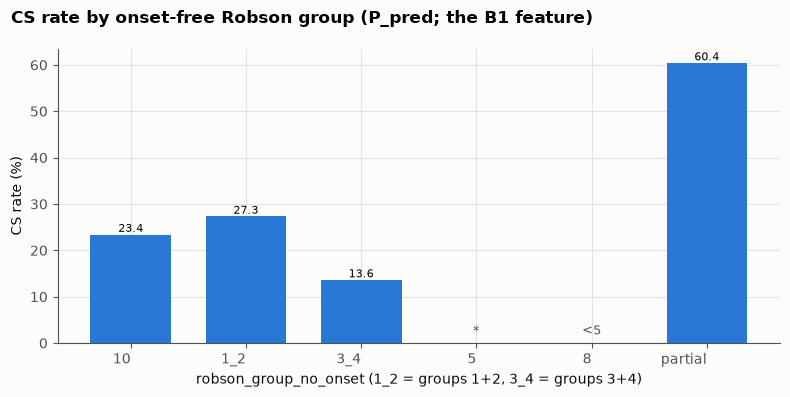

In [18]:
robson_rates = categorical_summary[categorical_summary["feature"] == "robson_group_no_onset"]
show(
    figures.bar_chart(
        robson_rates["level"].tolist(),
        robson_rates["rate_pct"].tolist(),
        "CS rate by onset-free Robson group (P_pred; the B1 feature)",
        "robson_group_no_onset (1_2 = groups 1+2, 3_4 = groups 3+4)",
        "CS rate (%)",
    )
)

### 4.4 Missingness by variable and facility (% missing, P_pred)

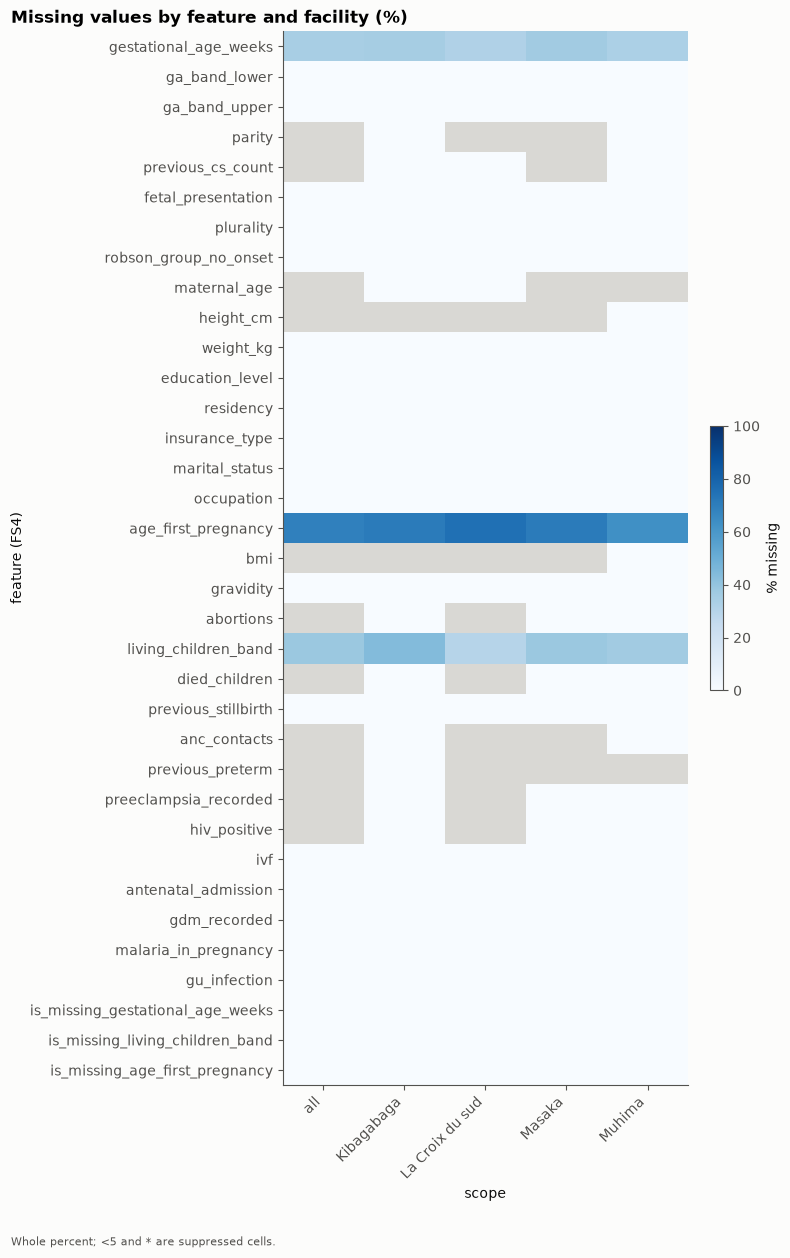

In [19]:
show(
    figures.heatmap(
        missingness,
        "Missing values by feature and facility (%)",
        "scope",
        "feature (FS4)",
        "% missing",
        vmin=0,
        vmax=100,
        note="Whole percent; <5 and * are suppressed cells.",
    )
)

### 4.5 Correlation of the numeric features

Spearman correlation on pairwise-complete rows. A pair needs at least
`eda.MIN_CORRELATION_N` complete rows to be shown.

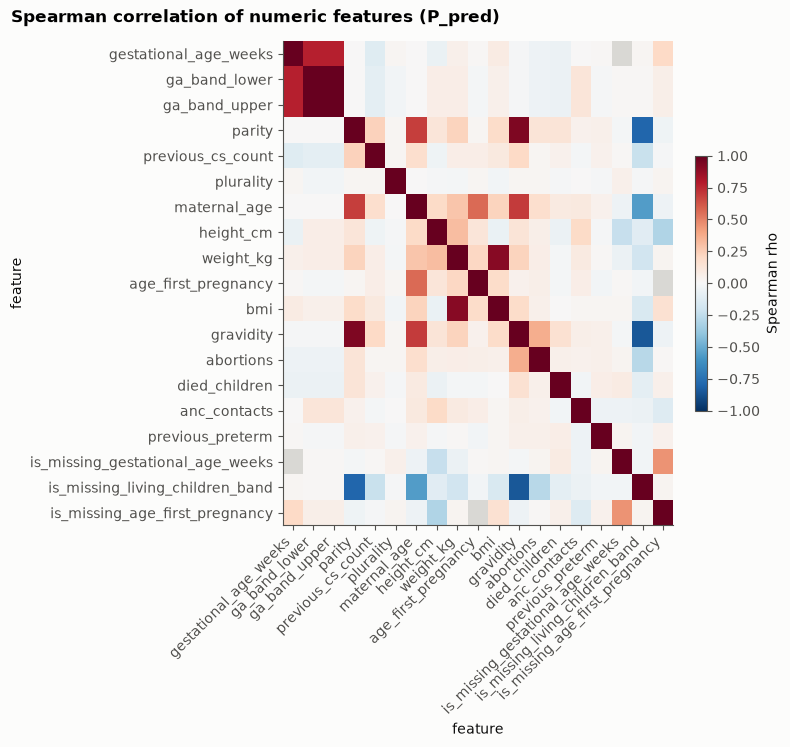

In [20]:
corr = eda.correlation_matrix(x4, list(fs4.numeric))
show(
    figures.heatmap(
        corr.round(2),
        "Spearman correlation of numeric features (P_pred)",
        "feature",
        "feature",
        "Spearman rho",
        cmap=figures.DIVERGING,
        vmin=-1,
        vmax=1,
        fmt="{:.1f}",
    )
)

### 4.6 Univariate association with CS

Two views of the same question, both from published outputs:

* **Variable profile** (all records): the single-feature AUC for numeric raw columns and Cramér's V for
  categorical ones.
* **Leakage screen** (P_audit): the leave-one-hospital-out single-feature AUC, where values above 0.85
  are flagged for review (§5).

In [21]:
association = profile_table.copy()
association["association"] = pd.to_numeric(association["association"], errors="coerce")
association = association[association["association"].notna()]
association["strength"] = np.where(
    association["association_metric"] == "auc",
    (association["association"] - 0.5).abs() * 2,
    association["association"],
)
top_association = association.sort_values("strength", ascending=False).head(15)
top_association[["raw_name", "canonical_name", "kind", "association_metric", "association"]].round(
    3
)

,raw_name,canonical_name,kind,association_metric,association
32,Mode of Delivery,mode_of_delivery;cs,categorical,cramers_v,1.000
30,Birth Attendant,,categorical,cramers_v,0.982
27,Labor Onset,onset_of_labour,categorical,cramers_v,0.692
35,Previous Scar,,categorical,cramers_v,0.617
54,Delivery Complicated by Perineal Tear,,categorical,cramers_v,0.480
67,Episiotomy/ Perineal Tear,,categorical,cramers_v,0.410
37,Fetal Distress,,categorical,cramers_v,0.300
109,Reason for Newborn Admission into NICU,,categorical,cramers_v,0.226
3,Maternal Age,maternal_age,numeric,auc,0.605
68,Oxytocin Use,,categorical,cramers_v,0.189


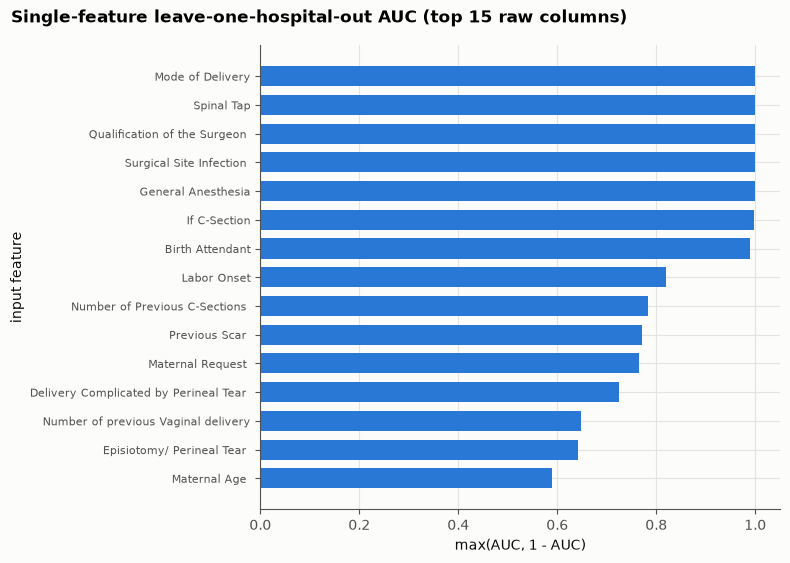

In [22]:
screens = pd.read_csv(REPORTS / "leakage" / "leakage_screens.csv")
screens["loho_auc_strength"] = np.maximum(screens["loho_auc"], 1 - screens["loho_auc"])
top_screen = screens.sort_values("loho_auc_strength", ascending=False).head(15)
show(
    figures.importance_bars(
        top_screen.set_index("variable"),
        "loho_auc_strength",
        "Single-feature leave-one-hospital-out AUC (top 15 raw columns)",
        "max(AUC, 1 - AUC)",
    )
)

### 4.7 Data-quality findings

**Parity definition.** In the register, "Parity" counts the current birth. Canonical parity is therefore
derived as *previous vaginal deliveries + previous CS* (top-coded at 4), and is missing when either part
is missing (DECISIONS 2026-09-23). Nulliparity follows from that derivation.

**Onset coded retrospectively (spec v1.3).** If the onset field recorded what was known at admission,
the share of CS coded "pre-labour CS" would be stable and well below 100%. The tables below show that
share by facility and month (among CS with a recorded onset), and the share among CS typed *emergency*.
A share near 100% means that "Planned C-section" onset often just means "had a CS". This is why onset is
excluded from every model and why P_pred was redefined in v1.3.

,n,n_nulliparous,nulliparous_pct
facility_id,,,
Kibagabaga,1325,512,38.6
La Croix du sud,742,171,23.0
Masaka,1664,646,38.8
Muhima,1786,602,33.7


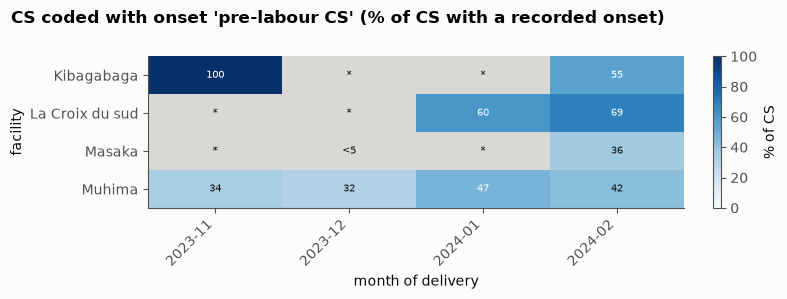

,emergency CS,coded pre-labour onset,%
facility_id,,,
Kibagabaga,237,168,70.9
La Croix du sud,144,9,6.2
Masaka,322,211,65.5
Muhima,451,31,6.9


In [23]:
nulliparous = audit.assign(
    nulliparous=(audit["parity"] == 0).astype(float).where(audit["parity"].notna())
)
display(
    eda.rate_by(nulliparous, "facility_id", "nulliparous")
    .rename(columns={"n_outcome": "n_nulliparous", "rate_pct": "nulliparous_pct"})
    .set_index("facility_id")
)
onset_share = eda.prelabour_onset_share(audit)
share_matrix = onset_share.pivot(index="facility_id", columns="period", values="rate_pct")
show(
    figures.heatmap(
        share_matrix,
        "CS coded with onset 'pre-labour CS' (% of CS with a recorded onset)",
        "month of delivery",
        "facility",
        "% of CS",
        vmin=0,
        vmax=100,
    )
)
emergency = audit[(audit["cs"] == 1) & (audit["prelabour_cs_type"] == "emergency")]
emergency = emergency.assign(
    prelabour_onset=(emergency["onset_of_labour"] == "prelabour_cs")
    .astype(float)
    .where(emergency["onset_of_labour"].notna())
)
eda.rate_by(emergency, "facility_id", "prelabour_onset").rename(
    columns={"n": "emergency CS", "n_outcome": "coded pre-labour onset", "rate_pct": "%"}
).set_index("facility_id")

## 5. Leakage audit and feature registry

The automatic screens (spec §8.2) only **flag** variables for human review, and they never exclude
anything:

1. a single-feature leave-one-hospital-out AUC above 0.85;
2. a name matching a post-admission or outcome-side pattern (indication, theatre, apgar, ...);
3. a completeness pattern, where the variable is recorded mostly when `cs = 1`.

Every exclusion in `configs/features_v1.yaml` was approved by hand before any model was trained
(Checkpoint 2), and model code reads only `status: include`.

In [24]:
flags = {
    "screened raw columns": len(screens),
    "AUC flag": int(screens["auc_flag"].sum()),
    "name flag": int(screens["name_flag"].sum()),
    "completeness flag": int(screens["completeness_flag"].sum()),
    "any flag": int(screens["flagged"].sum()),
}
display(pd.Series({k: fmt_count(v) for k, v in flags.items()}, name="columns").to_frame())

status_by_raw = {col: (e.name, e.status) for e in registry.entries for col in e.raw_name}
flagged = screens[screens["flagged"]].copy()
flagged["registry entry"] = flagged["variable"].map(lambda c: status_by_raw.get(c, ("-", "-"))[0])
flagged["registry status"] = flagged["variable"].map(lambda c: status_by_raw.get(c, ("-", "-"))[1])
flagged[
    [
        "variable",
        "loho_auc",
        "auc_flag",
        "name_flag",
        "completeness_flag",
        "registry entry",
        "registry status",
    ]
].round(3)

,columns
screened raw columns,115
AUC flag,7
name flag,50
completeness flag,6
any flag,54


,variable,loho_auc,auc_flag,name_flag,completeness_flag,registry entry,registry status
18,Number of Previous C-Sections,0.784,False,True,False,previous_cs_count,include
21,Duration of Labor,0.503,False,True,False,labour_duration,exclude
22,Birth Attendant,0.988,True,False,False,birth_attendant,exclude
23,Mode of Delivery,1.000,True,False,False,cs,exclude
24,If C-Section,0.997,True,True,True,prelabour_cs_type,exclude
25,Maternal Request,0.766,False,False,True,maternal_request,exclude
41,Time of Delivery,0.531,False,True,False,delivery_time,exclude
42,Twin baby,0.507,False,True,False,twin_baby,exclude
43,Birth Weight,0.502,False,True,False,birth_weight,exclude
44,Birth weight for twin baby,0.503,False,True,False,birth_weight_twin,exclude


In [25]:
included = pd.DataFrame(
    [
        {"group": e.group, "feature": e.name, "source": e.source, "reason": e.reason}
        for e in registry.included()
    ]
)
included["group"] = pd.Categorical(included["group"], categories=list(GROUP_ORDER), ordered=True)
missing_from_registry, not_in_export = check_coverage(registry, [str(c) for c in raw.columns])
print(
    f"registry {registry.path.name}: sha256 {registry.sha256}; entries {len(registry.entries)}; "
    f"included {len(included)}"
)
print(
    f"coverage: raw columns missing from the registry: {len(missing_from_registry)}; "
    f"registry columns not in the export: {len(not_in_export)}"
    + (" (synthetic export: expected)" if MODE == "synthetic" else "")
)
included.sort_values(["group", "feature"]).set_index(["group", "feature"])

registry features_v1.yaml: sha256 08901a41d47d57927e80a57580ad2ff61d79e42f5af35a490822472be989346a; entries 165; included 34
coverage: raw columns missing from the registry: 0; registry columns not in the export: 0


source  \
group      feature                                       
G_robson   fetal_presentation                canonical   
           gestational_age_band              canonical   
           gestational_age_weeks             canonical   
           parity                            canonical   
           plurality                         canonical   
           previous_cs_count                 canonical   
           robson_group_no_onset               derived   
G_maternal age_first_pregnancy                     raw   
           bmi                                 derived   
           education_level                         raw   
           height_cm                         canonical   
           insurance_type                          raw   
           marital_status                          raw   
           maternal_age                      canonical   
           occupation                              raw   
           residency                               raw   
           weight_kg                         canonical   
G_obs      abortions                               raw   
           anc_contacts                      canonical   
           antenatal_admission                     raw   
           died_children                           raw   
           gdm_recorded                      canonical   
           gravidity                               raw   
           gu_infection                            raw   
           hiv_positive                            raw   
           ivf                                     raw   
           living_children_band                    raw   
           malaria_in_pregnancy                    raw   
           preeclampsia_recorded             canonical   
           previous_preterm                        raw   
           previous_stillbirth                     raw   
G_missing  is_missing_age_first_pregnancy      derived   
           is_missing_gestational_age_weeks    derived   
           is_missing_living_children_band     derived   

                                                                                                                      reason  
group      feature                                                                                                            
G_robson   fetal_presentation                Only presentation information (yes/no), but sits in the CS-indication block;...  
           gestational_age_band              Banded gestational age at labour; Robson input (interval) when exact GA missing  
           gestational_age_weeks                                           Gestational age of the same episode; Robson input  
           parity                            Previous births = previous vaginal + previous CS (derived, user decision); R...  
           plurality                                                                   General pregnancy field; Robson input  
           previous_cs_count                                    Obstetric history; Robson input; also used in derived parity  
           robson_group_no_onset                         Robson group computed without onset; 1+2 and 3+4 merged (spec v1.3)  
G_maternal age_first_pregnancy                                                           Obstetric history (partly recorded)  
           bmi                                                               weight_kg / (height_cm/100)^2 when both present  
           education_level                                                              Sociodemographic, known at admission  
           height_cm                                                                   Maternal characteristic; used for BMI  
           insurance_type                                                               Sociodemographic, known at admission  
           marital_status                                                               Sociodemographic, known at admission  
           maternal_age                               

## 6. Populations

| Population | Definition (spec v1.3) |
|---|---|
| `P_audit` | Every record with a known mode of delivery. Used for the Robson tables and case mix. |
| `P_pred` | `P_audit` minus admissions with a **CS already planned at admission**: CS typed elective/planned, and "planned C-section" onset followed by a vaginal birth. CS with no recorded type are kept and counted. This mirrors deployment: a planned CS gets a Robson group but no readiness score. |

The exclusions are protected jointly: the excluded categories and `P_pred` add up to `P_audit`, and the
per-facility differences between the two populations are counts in their own right.

In [26]:
pred_frame, pred_logs = prediction_population(audit)
table = data.exclusion_table.set_index("category")
flow = pd.DataFrame(
    {
        "n": [int(table.loc[c, "n_excluded"]) for c in table.index[:2]] + [len(pred_frame)],
        "n_cs": [int(table.loc[c, "n_cs_excluded"]) for c in table.index[:2]]
        + [int(pred_frame["cs"].sum())],
    },
    index=[*(f"excluded: {c}" for c in table.index[:2]), "P_pred"],
)
flow_safe = suppress_table(flow, ["n", "n_cs"], complements={"n_cs": "n"})
print(
    f"canonical records: {fmt_count(len(classified))}; missing outcome (reported exactly, "
    f"spec 4.2): {audit_log.n_excluded}; P_audit: {fmt_count(len(audit))}, of which CS "
    f"{fmt_count(int(audit['cs'].sum()))}"
)
display(flow_safe.rename_axis("P_audit ="))
kept_untyped = int(table.loc[table.index[2], "n_kept"])
typed_rest = int(pred_frame["cs"].sum()) - kept_untyped
shown = fmt_count(kept_untyped) if not 0 < typed_rest < 5 else SECONDARY
print(f"CS with no recorded type kept in P_pred: {shown}")

canonical records: 5520; missing outcome (reported exactly, spec 4.2): 0; P_audit: 5520, of which CS 2403


,n,n_cs
P_audit =,,
excluded: planned CS (elective type),1238,1238
"excluded: planned-CS onset, vaginal birth",17,0
P_pred,4265,1165


CS with no recorded type kept in P_pred: 11


n n_outcome rate_pct
population facility_id                             
P_audit    Kibagabaga       1325       563     42.5
           La Croix du sud   743       478     64.3
           Masaka           1665       585     35.1
           Muhima           1787       777     43.5
P_pred     Kibagabaga       1002       246     24.6
           La Croix du sud   411       146     35.5
           Masaka           1391       322     23.1
           Muhima           1461       451     30.9

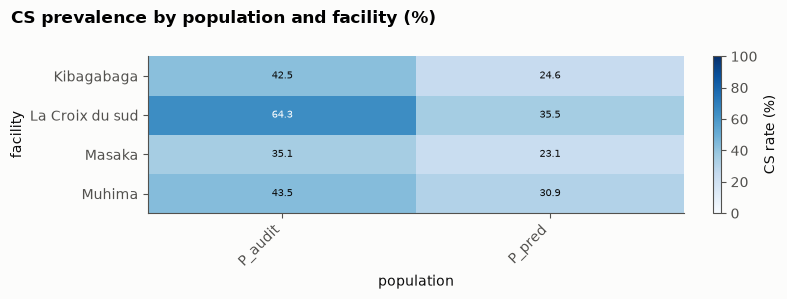

In [27]:
prevalence = eda.nested_population_rates({"P_audit": audit, "P_pred": pred_frame})
display(prevalence.set_index(["population", "facility_id"]))
wide = prevalence.pivot(index="facility_id", columns="population", values="rate_pct")
show(
    figures.heatmap(
        wide,
        "CS prevalence by population and facility (%)",
        "population",
        "facility",
        "CS rate (%)",
        vmin=0,
        vmax=100,
        fmt="{:.1f}",
    )
)

## 7. Preprocessing

### Feature sets (spec §9.2, v1.3)

| Set | Contents | Question |
|---|---|---|
| FS0 | G_robson: parity, previous CS, presentation, plurality, GA (exact and band), `robson_group_no_onset` | How far does Robson alone go? |
| FS1 | FS0 + G_maternal (age, anthropometry, BMI, sociodemographics) | |
| FS2 | FS1 + G_obs (admission-time observations and history) | Do admission observations add signal? |
| FS3 | FS2 + G_missing (`is_missing_<field>`) | Is missingness informative? |
| FS4 | FS3 + G_context (no facility) | The full set that can be evaluated leave-one-hospital-out |
| FS4_deploy | FS4 + `facility_id` | Deployment variant, internal evaluation only |

Onset of labour is **never** a feature, because it is outcome-contaminated (v1.3). The Robson feature is
computed without onset, so groups 1+2 and 3+4 merge.

In [28]:
membership = pd.DataFrame(
    {
        name: [c in feature_spec(data, name).columns for c in data.x.columns]
        for name in FEATURE_SETS
    },
    index=data.x.columns,
).replace({True: "x", False: ""})
membership.insert(0, "kind", [data.kinds[c] for c in data.x.columns])
membership.insert(0, "group", [data.groups[c] for c in data.x.columns])
display(membership)
pd.DataFrame(
    {
        name: {
            "features": len(spec.columns),
            "categorical": len(spec.categorical),
            "numeric": len(spec.numeric),
        }
        for name, spec in ((n, feature_spec(data, n)) for n in FEATURE_SETS)
    }
)

,group,kind,FS0,FS1,FS2,FS3,FS4,FS0_deploy,FS1_deploy,FS2_deploy,FS3_deploy,FS4_deploy
gestational_age_weeks,G_robson,numeric,x,x,x,x,x,x,x,x,x,x
ga_band_lower,G_robson,numeric,x,x,x,x,x,x,x,x,x,x
ga_band_upper,G_robson,numeric,x,x,x,x,x,x,x,x,x,x
parity,G_robson,numeric,x,x,x,x,x,x,x,x,x,x
previous_cs_count,G_robson,numeric,x,x,x,x,x,x,x,x,x,x
fetal_presentation,G_robson,categorical,x,x,x,x,x,x,x,x,x,x
plurality,G_robson,numeric,x,x,x,x,x,x,x,x,x,x
robson_group_no_onset,G_robson,categorical,x,x,x,x,x,x,x,x,x,x
maternal_age,G_maternal,numeric,,x,x,x,x,,x,x,x,x
height_cm,G_maternal,numeric,,x,x,x,x,,x,x,x,x


,FS0,FS1,FS2,FS3,FS4,FS0_deploy,FS1_deploy,FS2_deploy,FS3_deploy,FS4_deploy
features,8,18,32,35,35,9,19,33,36,36
categorical,2,7,16,16,16,3,8,17,17,17
numeric,6,11,16,19,19,6,11,16,19,19


### Missing-data strategies (spec §10)

| ID | Strategy | Applies to |
|---|---|---|
| M0 | Pass NaN through (native handling) | XGBoost, and the untuned baselines B0/B1 |
| M1 | Median imputation (numeric) and mode imputation (categorical), plus missing indicators | All |
| M2 | `IterativeImputer` on numerics (single imputation), mode for categoricals, plus missing indicators | All |

### The model Pipelines

Every fitted transformation (imputation, one-hot or native-categorical encoding, scaling, and splines
for the logistic baselines) sits in the Pipeline's `prep` step. The harness fits the Pipeline on each
fold's **fit rows only**, so nothing is learned from calibration or test rows. The calibrator (§11) is
then fitted on the separate calibration split. Below are unfitted Pipelines for the P0 models and the
baselines.

In [29]:
sklearn.set_config(display="diagram")
EXAMPLE_PARAMS = {
    "logreg_l2": {"C": 1.0},
    "xgboost": {"learning_rate": 0.05, "max_depth": 4},
    "mlp": {"hidden_layer_sizes": "64", "alpha": 1e-4, "learning_rate_init": 1e-3},
    "B2": {"C": 1.0},
    "B3": {"C": 1.0},
}
PIPELINES = [
    ("B1", "FS0", "M0"),
    ("logreg_l2", "FS4", "M1"),
    ("logreg_l2", "FS4", "M2"),
    ("xgboost", "FS4", "M0"),
    ("mlp", "FS4", "M1"),
]
spec_rows = []
for name, fs_name, strategy in PIPELINES:
    spec = get_model(name)
    params = {**EXAMPLE_PARAMS.get(name, {}), "missing_strategy": strategy, "seed": SEED}
    pipe = spec.build(params, feature_spec(data, fs_name))
    display(Markdown(f"**{name}** on {fs_name}, {strategy}"))
    display(pipe)
for name, spec in sorted(MODEL_REGISTRY.items()):
    spec_rows.append(
        {
            "model": name,
            "family": spec.family,
            "complexity rank": spec.complexity_rank,
            "missing strategies": ", ".join(spec.strategies()),
            "tuning": "grid" if spec.grid else ("none" if spec.grid == {} else "Optuna TPE"),
        }
    )
pd.DataFrame(spec_rows).set_index("model")

**B1** on FS0, M0

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('keep', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""

**logreg_l2** on FS4, M1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

**logreg_l2** on FS4, M2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

**xgboost** on FS4, M0

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

**mlp** on FS4, M1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

,family,complexity rank,missing strategies,tuning
model,,,,
B0,baseline,0,"M0, M1, M2",none
B1,baseline,0,"M0, M1, M2",none
B2,baseline,0,"M1, M2",grid
B3,baseline,0,"M1, M2",grid
logreg_l2,linear,1,"M1, M2",Optuna TPE
mlp,neural,7,"M1, M2",Optuna TPE
xgboost,tree,5,"M0, M1, M2",Optuna TPE


## 8. Evaluation design

| Scheme | Design (spec §11.1) | Role |
|---|---|---|
| **S1** LOHO | Each hospital is held out in turn. 20% of the training pool (stratified by CS × facility and grouped by mother) is the calibration split. Hyperparameters are tuned on the remaining 80% with facility-grouped CV, the model is refit, the calibrator is fitted on the calibration split, and the held-out hospital is evaluated | **Primary**; the selection rule reads it |
| **S2** LOHO + local recalibration | As S1, then the held-out hospital's first 150 admissions (by delivery date) refit the intercept only. The rest are evaluated | Transport with a local update |
| **S3** internal nested CV | Outer StratifiedGroupKFold(5), with a 20% calibration split and inner CV(3) for tuning | Only to size the internal-vs-LOHO gap |
| S4 temporal | Train November-January, test February-March | P1 |
| S5 deployment | All hospitals, 80/20 fit/calibration | Produces the artefact (not an evaluation) |

A woman's rows never straddle the fit, calibration and test sets: splits are grouped by `mother_key`,
and any training-side rows of a woman who has a held-out row are dropped (*excluded*).

,fit,calibration,excluded (shared mother),test
loho_Kibagabaga,2610,653,0,1002
loho_La Croix du sud,3082,771,<5,*
loho_Masaka,2299,575,0,1391
loho_Muhima,2243,*,<5,1461


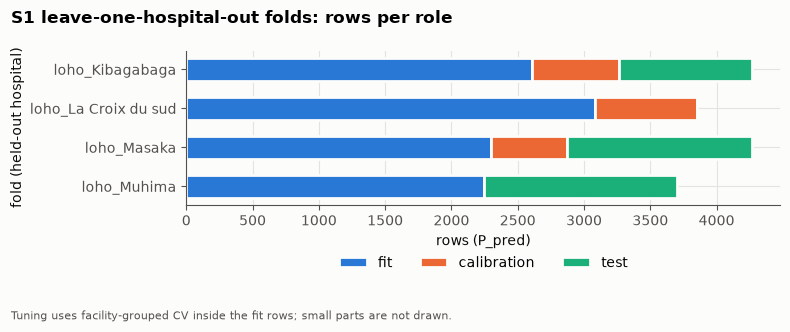

,fit,calibration,excluded (shared mother),test
internal_0,2729,683,0,853
internal_1,2730,682,0,853
internal_2,2729,683,0,853
internal_3,2729,683,0,853
internal_4,2729,683,0,853


In [30]:
def fold_sizes(folds) -> pd.DataFrame:
    # Rows per role in each fold: a partition of the population, suppressed as one.
    total = len(data.meta)
    sizes = pd.DataFrame(
        {
            f.name: {
                "fit": len(f.fit_idx),
                "calibration": len(f.calib_idx),
                "excluded (shared mother)": len(f.excluded_idx),
                "test": len(f.test_idx),
            }
            for f in folds
        }
    ).T
    if not (sizes.sum(axis=1) == total).all():
        raise AssertionError("fold parts must partition the population")
    return eda.suppress_partition(sizes, list(sizes.columns))


s1_folds = make_folds(data.meta, "S1", SEED)
s1_sizes = fold_sizes(s1_folds)
display(s1_sizes)
show(
    figures.stacked_bars(
        s1_sizes[["fit", "calibration", "test"]].T,
        "S1 leave-one-hospital-out folds: rows per role",
        "rows (P_pred)",
        "fold (held-out hospital)",
        note="Tuning uses facility-grouped CV inside the fit rows; small parts are not drawn.",
    )
)
s3_sizes = fold_sizes(make_folds(data.meta, "S3", SEED))
s3_sizes

In [31]:
recal_rows = []
for fold in s1_folds:
    recal, rest = recalibration_split(fold.test_idx, data.meta)
    recal_rows.append(
        {
            "fold": fold.name,
            "recalibration (first 150)": len(recal),
            "evaluated": len(rest),
            "dropped (shared mother)": len(fold.test_idx) - len(recal) - len(rest),
        }
    )
# The first 150 are fixed by design; the rest of each held-out hospital splits into
# evaluated and dropped rows, a partition protected as one.
recal_table = pd.DataFrame(recal_rows).set_index("fold")
eda.suppress_partition(recal_table, ["evaluated", "dropped (shared mother)"])

,recalibration (first 150),evaluated,dropped (shared mother)
fold,,,
loho_Kibagabaga,150,852,0
loho_La Croix du sud,150,261,0
loho_Masaka,150,*,<5
loho_Muhima,150,*,<5


### Metrics (spec §11.3)

| Metric | Definition |
|---|---|
| AUC | ROC AUC with a 95% CI from a stratified bootstrap |
| Calibration slope | β in logit P(cs=1) = α + β·logit(p). 1 is ideal; below 1 means predictions are too extreme |
| Calibration-in-the-large | α with logit(p) as an offset. 0 is ideal |
| Brier score | Mean squared error of p, with the Murphy decomposition |
| Net benefit | TP/n − FP/n × pt/(1−pt) over thresholds 0.10-0.90, compared with treat-all and treat-none |
| Log loss | The tuning objective |

Per-site metrics are summarised by their **mean and range across the four held-out hospitals**, and
pooled metrics are reported alongside them (spec §11.6). Subgroups with fewer than 50 rows, or fewer than
10 events in either class, report `insufficient` (§11.4).

### Pre-registered selection rule

`configs/selection_rule.yaml` was committed **before any model was run on real data** (spec §13.2). The
harness refuses a real-data run if the file is modified or uncommitted.

In [32]:
rule = load_selection_rule(SELECTION_RULE_PATH)
print(f"selection rule commit: {selection_rule_commit(REPO)}")
display(Markdown(f"```yaml\n{rule.text.strip()}\n```"))

selection rule commit: 2833b51d998853cc31d3c70ac5d8e339f9d17814


```yaml
# Pre-registered model selection rule (spec §13.2-13.3). Committed before any model is run on real data.
version: 1
eligible:
  split: S1                      # leave-one-hospital-out
  population: P_pred
  feature_sets: [FS0, FS1, FS2, FS3, FS4]
  mean_calibration_slope: [0.8, 1.2]
rank_by: mean_loho_auc
tie_break:
  within_auc: 0.01
  prefer: lowest_complexity_rank
baseline_check:
  baseline: B1                   # Robson-group lookup
  if_not_exceeded: report "the model does not add discrimination beyond the Robson classification"; still package the best-calibrated configuration and flag it in the manifest
fallback_if_none_eligible: select the configuration whose mean calibration slope is closest to 1.0 and report as a limitation
baselines_selectable: false      # B0-B3 are comparators, not candidates
```

## 9. Training

Each configuration (model, feature set, missing strategy, split, population, seed, trials) is one
`evaluate.run_experiment` call. For every fold, the harness:

1. **tunes** with Optuna TPE (seeded), minimising the inner-CV mean log loss (boosting early-stops on each
   inner validation fold);
2. **refits** the Pipeline on the fit rows with the best hyperparameters;
3. **calibrates**, choosing none, Platt or isotonic by 5-fold cross-validated Brier score *within the
   calibration split*, then refitting the chosen method on the whole split;
4. **predicts** the held-out rows (S2 first recalibrates the intercept on the first 150).

Everything is logged to MLflow: params, per-fold, mean, range and pooled metrics, aggregate plots, and
provenance tags (data hash, registry hash, git and selection-rule commits, population version). The
out-of-fold predictions go to `data/interim/oof/`, never to MLflow.

In **synthetic** mode a small grid runs live now, with few trials. In **real** mode results are read from
`mlruns/`. A single demonstration run happens only with `RUN_LIVE`, goes to a temporary store, and is
refused unless the selection rule is committed.

In [33]:
# (model, feature set, missing strategy, split): kept tiny (memory and time); S2/S3 and
# the full grid appear in real mode, read from mlruns/.
SYNTHETIC_GRID = [
    ExperimentConfig(m, f, s, sp, "P_pred", SYNTHETIC_TRIALS, SEED, SYNTHETIC_BOOT)
    for m, f, s, sp in [
        ("B1", "FS0", "M0", "S1"),
        ("logreg_l2", "FS1", "M1", "S1"),
        ("xgboost", "FS0", "M0", "S1"),
    ]
]
DEMO_CONFIG = ExperimentConfig("logreg_l2", "FS0", "M1", "S1", "P_pred", 5, SEED, 200)

live_results = []
if MODE == "synthetic":
    ctx = RunContext(
        tracking_uri=TRACKING_URI,
        oof_dir=OOF_DIR,
        data_hash=file_sha256(CLASSIFIED_PATH),
        features_yaml_hash=registry.sha256,
        git_commit=git_commit(REPO),
        selection_rule_commit=selection_rule_commit(REPO),
    )
    started = time.time()
    live_results = [run_experiment(config, data, ctx) for config in SYNTHETIC_GRID]
    print(f"{len(live_results)} synthetic configurations in {time.time() - started:.0f} s")
elif RUN_LIVE:
    rule_commit = check_preregistration(REPO)  # refuses unless the rule is committed
    live_dir = Path(tempfile.mkdtemp(prefix="robson_live_"))
    ctx = RunContext(
        tracking_uri=(live_dir / "mlruns").as_uri(),
        oof_dir=live_dir / "oof",
        data_hash=file_sha256(CLASSIFIED_PATH),
        features_yaml_hash=registry.sha256,
        git_commit=git_commit(REPO),
        selection_rule_commit=rule_commit,
    )
    live_results = [run_experiment(DEMO_CONFIG, data, ctx)]
    print(f"demonstration run tracked in a temporary store: {live_dir}")
else:
    print("real mode: no live training; results are read from mlruns/ below")

if live_results:
    display(
        pd.DataFrame(
            [
                {
                    "configuration": r.config.name,
                    "mean AUC": r.summary["mean_auc"],
                    "min AUC": r.summary["min_auc"],
                    "max AUC": r.summary["max_auc"],
                    "pooled AUC": r.summary["pooled_auc"],
                    "mean slope": r.summary["mean_calibration_slope"],
                }
                for r in live_results
            ]
        )
        .set_index("configuration")
        .round(3)
    )

real mode: no live training; results are read from mlruns/ below


In [34]:
# One run in detail: per fold, the tuned hyperparameters and the calibration choice
# (cross-validated Brier of each option within the calibration split).
if live_results:
    demo = next((r for r in live_results if r.config.model == "logreg_l2"), live_results[0])
    detail = pd.DataFrame(
        {
            f.fold.name: {
                **{k: v for k, v in f.params.items() if k not in ("missing_strategy", "seed")},
                "calibration": f.model.choice.method,
                **{f"CV Brier {k}": round(v, 4) for k, v in f.model.choice.cv_brier.items()},
                "held-out AUC": round(f.metrics["auc"], 3),
            }
            for f in demo.folds
        }
    ).T
    display(Markdown(f"**{demo.config.name}**"))
    display(detail)

## 10. Results and comparison

All finished runs of the **current population version** (`POPULATION_VERSION`) are read from MLflow.
Earlier runs (the onset-defined P_pred) are left out, and a configuration run more than once keeps only
its latest run.

In [35]:
runs = load_runs(TRACKING_URI)
comparison = comparison_table(TRACKING_URI)
print(
    f"runs of population version {POPULATION_VERSION}: {len(comparison)}; "
    f"distinct configurations: {len(runs)}"
)
columns = [
    "model",
    "feature_set",
    "missing_strategy",
    "split",
    "population",
    "mean_auc",
    "min_auc",
    "max_auc",
    "pooled_auc",
    "mean_calibration_slope",
    "mean_calibration_in_the_large",
    "pooled_brier",
]
runs[columns].round(3)

runs of population version v1.3: 73; distinct configurations: 73


,model,feature_set,missing_strategy,split,population,mean_auc,min_auc,max_auc,pooled_auc,mean_calibration_slope,mean_calibration_in_the_large,pooled_brier
0,B0,FS0,M0,S1,P_pred,0.500,0.500,0.500,0.443,1.659149e+13,0.117,0.201
1,B1,FS0,M0,S1,P_pred,0.730,0.686,0.792,0.715,1.048000e+00,0.045,0.163
2,B1,FS4,M0,S1,P_pred_onset_coded,0.727,0.658,0.844,0.687,8.690000e-01,-0.074,0.150
3,B2,FS0,M1,S1,P_pred,0.737,0.683,0.799,0.727,1.006000e+00,0.024,0.155
4,B3,FS4,M1,S1,P_pred,0.751,0.706,0.818,0.733,9.790000e-01,0.039,0.161
...,...,...,...,...,...,...,...,...,...,...,...,...
68,xgboost,FS4,M0,S3,P_pred,0.774,0.753,0.797,0.772,1.004000e+00,0.001,0.145
69,xgboost,FS4,M1,S3,P_pred,0.771,0.752,0.794,0.768,1.011000e+00,0.000,0.146
70,xgboost,FS4,M2,S3,P_pred,0.772,0.755,0.788,0.772,9.280000e-01,-0.002,0.146
71,B1,FS0,M0,S4,P_pred,0.725,0.725,0.725,0.725,1.239000e+00,-0.013,0.150


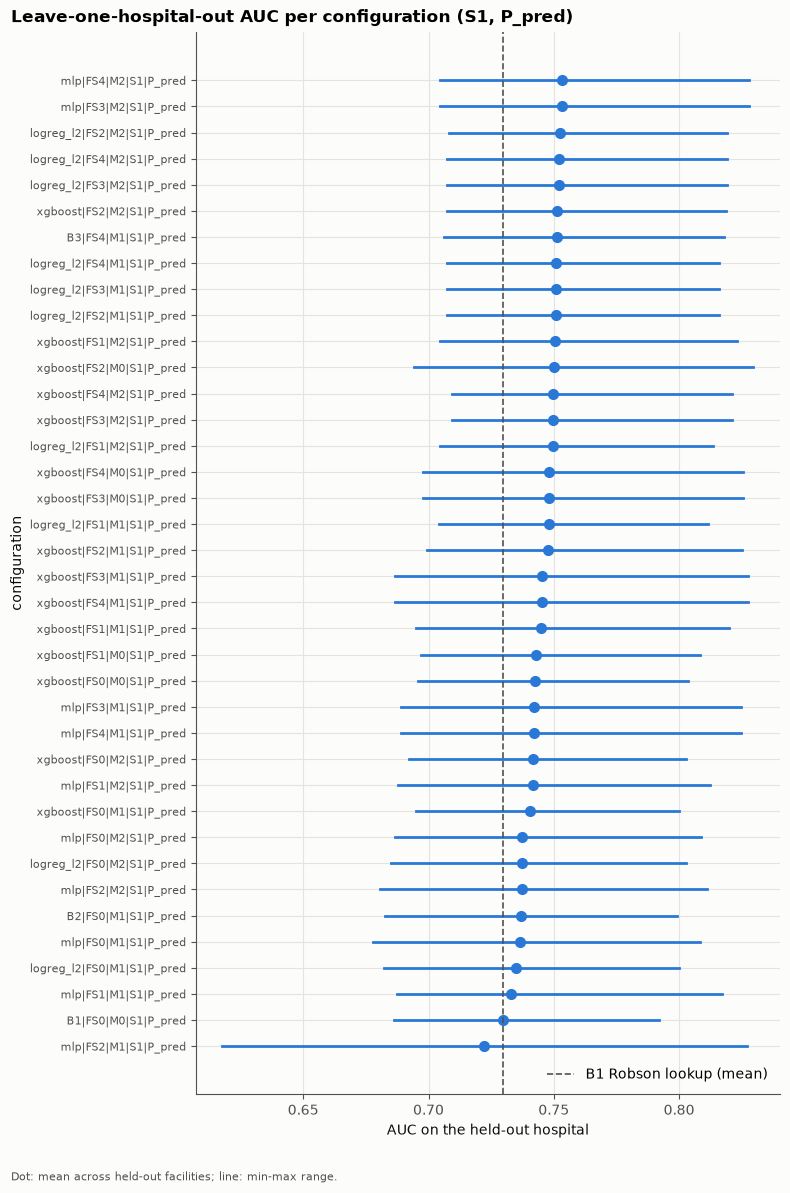

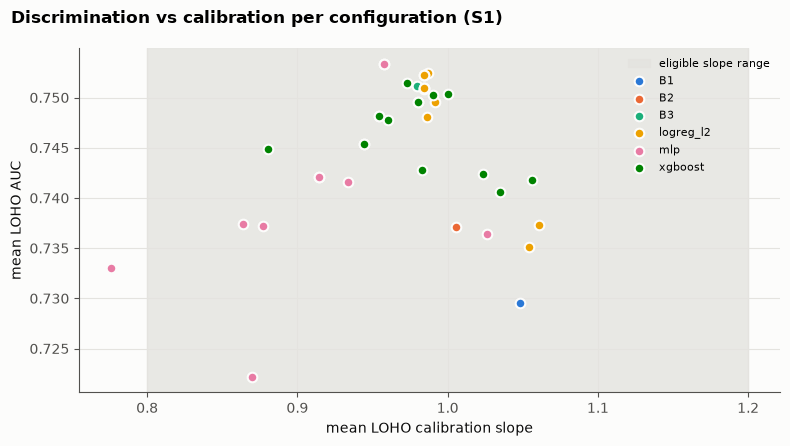

In [36]:
s1 = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred")].copy()
b1_rows = s1[s1["model"] == "B1"]
b1_auc = float(b1_rows["mean_auc"].iloc[0]) if len(b1_rows) else None
s1_models = s1[~s1["model"].isin(["B0"])].sort_values("mean_auc", ascending=False)
if s1_models.empty:
    raise RuntimeError("no S1 run of the current population version in MLflow yet")
show(
    figures.range_plot(
        s1_models,
        "config",
        "mean_auc",
        "min_auc",
        "max_auc",
        "Leave-one-hospital-out AUC per configuration (S1, P_pred)",
        "AUC on the held-out hospital",
        reference=b1_auc,
        reference_label="B1 Robson lookup (mean)",
    )
)
show(
    figures.scatter_groups(
        s1[~s1["model"].isin(["B0"])],
        "mean_calibration_slope",
        "mean_auc",
        "model",
        "Discrimination vs calibration per configuration (S1)",
        "mean LOHO calibration slope",
        "mean LOHO AUC",
        xband=rule.slope_range,
        band_label="eligible slope range",
    )
)

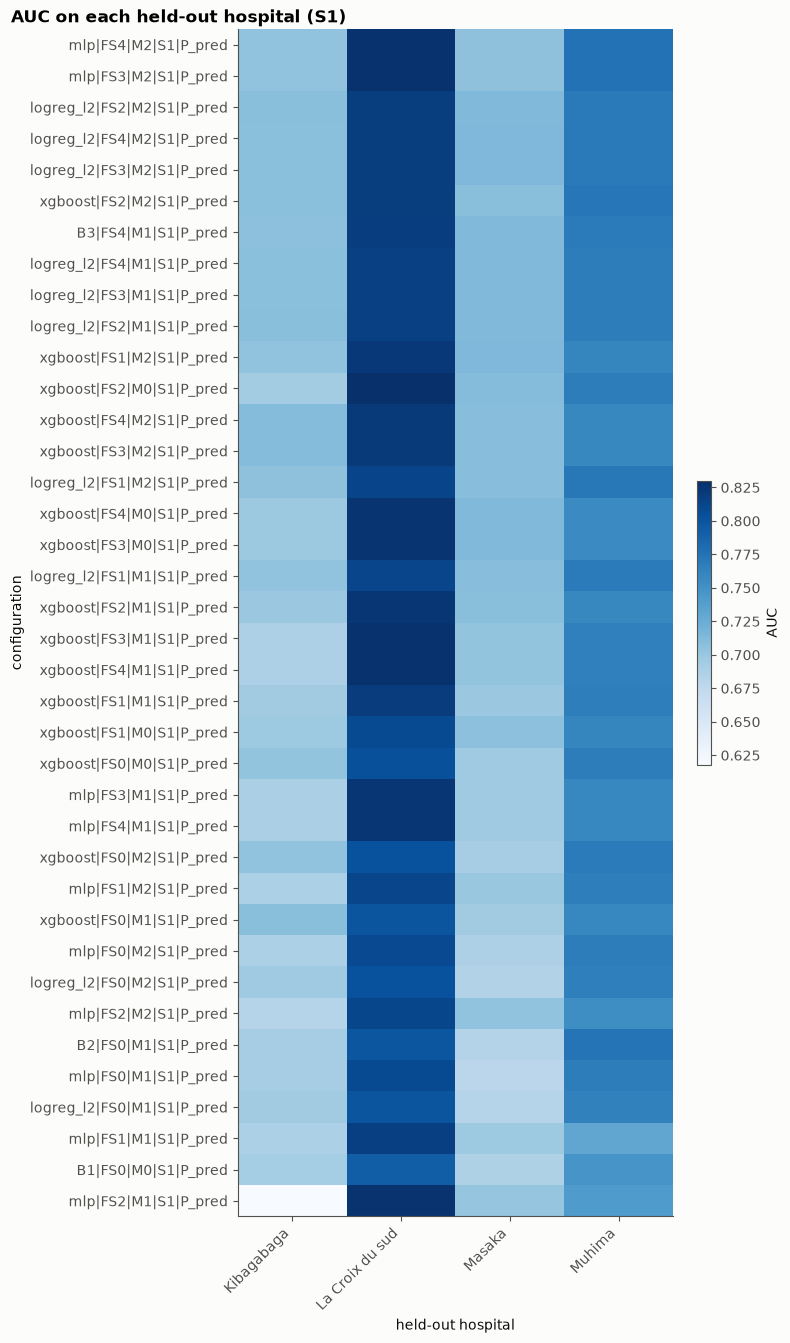

In [37]:
fold_names = [f.name for f in s1_folds]
per_hospital = fold_metrics(s1_models, fold_names, "auc")
per_hospital.columns = [c.removeprefix("loho_") for c in per_hospital.columns]
show(
    figures.heatmap(
        per_hospital.round(3),
        "AUC on each held-out hospital (S1)",
        "held-out hospital",
        "configuration",
        "AUC",
        fmt="{:.2f}",
    )
)

In [38]:
key = ["model", "feature_set", "missing_strategy"]
internal = runs[runs["split"] == "S3"][[*key, "mean_auc"]].rename(
    columns={"mean_auc": "S3 mean AUC"}
)
loho = s1[[*key, "mean_auc"]].rename(columns={"mean_auc": "S1 mean LOHO AUC"})
gap = internal.merge(loho, on=key)
gap["internal - LOHO"] = gap["S3 mean AUC"] - gap["S1 mean LOHO AUC"]
display(Markdown("**Internal (S3) vs leave-one-hospital-out (S1) discrimination**"))
display(gap.round(3) if len(gap) else Markdown("_No configuration has both S1 and S3 runs._"))

s2 = runs[runs["split"] == "S2"]
cols = ["mean_calibration_in_the_large", "mean_calibration_slope", "mean_auc"]
recal = s1[[*key, *cols]].merge(s2[[*key, *cols]], on=key, suffixes=(" S1", " S2"))
display(Markdown("**S2 local intercept recalibration: calibration before (S1) and after (S2)**"))
display(recal.round(3) if len(recal) else Markdown("_No configuration has both S1 and S2 runs._"))
print(
    "S2 evaluates each hospital after its first 150 admissions, so S1 and S2 are not "
    "evaluated on identical rows; the comparison is indicative."
)

**Internal (S3) vs leave-one-hospital-out (S1) discrimination**

,model,feature_set,missing_strategy,S3 mean AUC,S1 mean LOHO AUC,internal - LOHO
0,B0,FS0,M0,0.500,0.500,0.000
1,B1,FS0,M0,0.722,0.730,-0.008
2,B2,FS0,M1,0.729,0.737,-0.008
3,B3,FS4,M1,0.763,0.751,0.011
4,logreg_l2,FS2,M2,0.763,0.752,0.011
5,logreg_l2,FS4,M1,0.764,0.751,0.013
6,logreg_l2,FS4,M2,0.763,0.752,0.011
7,mlp,FS4,M1,0.761,0.742,0.019
8,mlp,FS4,M2,0.765,0.753,0.012
9,xgboost,FS4,M0,0.774,0.748,0.025


**S2 local intercept recalibration: calibration before (S1) and after (S2)**

,model,feature_set,missing_strategy,mean_calibration_in_the_large S1,mean_calibration_slope S1,mean_auc S1,mean_calibration_in_the_large S2,mean_calibration_slope S2,mean_auc S2
0,B0,FS0,M0,0.117,1.659149e+13,0.500,0.028,-3.649675e+12,0.500
1,B1,FS0,M0,0.045,1.048000e+00,0.730,0.197,1.132000e+00,0.730
2,B2,FS0,M1,0.024,1.006000e+00,0.737,0.073,1.001000e+00,0.734
3,B3,FS4,M1,0.039,9.790000e-01,0.751,-0.113,9.880000e-01,0.752
4,logreg_l2,FS4,M1,0.053,9.840000e-01,0.751,-0.116,9.930000e-01,0.752
5,logreg_l2,FS4,M2,0.052,9.840000e-01,0.752,-0.118,9.930000e-01,0.753
6,mlp,FS4,M1,-0.007,9.140000e-01,0.742,-0.108,9.000000e-01,0.742
7,mlp,FS4,M2,-0.001,9.570000e-01,0.753,-0.107,9.570000e-01,0.754
8,xgboost,FS4,M0,0.010,9.540000e-01,0.748,-0.004,9.620000e-01,0.746
9,xgboost,FS4,M1,0.015,9.450000e-01,0.745,0.055,9.500000e-01,0.743


S2 evaluates each hospital after its first 150 admissions, so S1 and S2 are not evaluated on identical rows; the comparison is indicative.


## 11. Calibration and clinical utility

The curves are computed from the **pooled out-of-fold predictions** of S1 for the best configurations by
mean LOHO AUC, with B1 for reference. Only the outcome and probability columns of each file are read.
Calibration bins are quantiles of the predicted probability, and any bin with fewer than
`eda.MIN_CALIBRATION_BIN` rows, or with 1-4 events or non-events, is merged into a neighbour. The
decision curve is an aggregate (net benefit per threshold). It shows how useful the signal is for
*anticipating theatre demand*. It is not a threshold for deciding any woman's care.

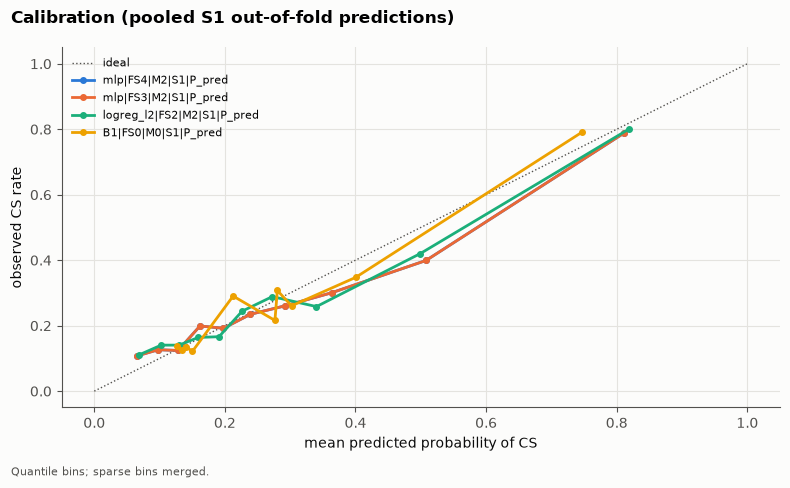

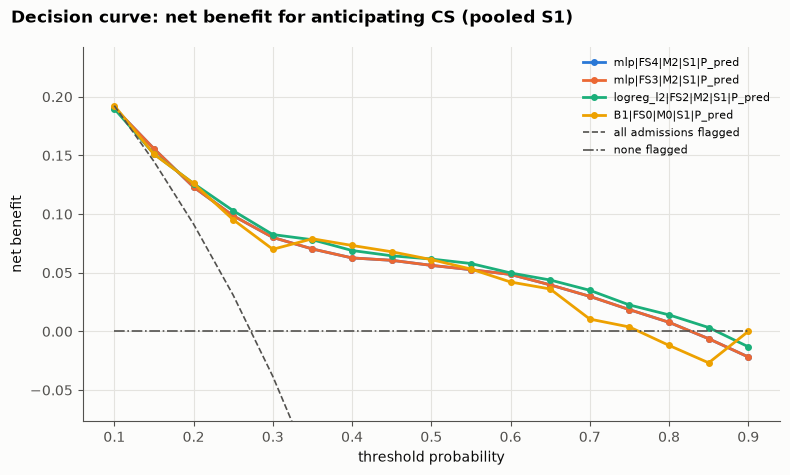

In [39]:
def load_oof(run_id: str) -> pd.DataFrame | None:
    path = OOF_DIR / f"{run_id}.parquet"
    return pd.read_parquet(path, columns=["y", "p"]) if path.exists() else None


candidates = s1_models[~s1_models["model"].isin(["B0", "B1", "B2", "B3"])].head(3)
shown_runs = pd.concat([candidates, b1_rows.head(1)])
calibration_curves, decision_curves = {}, {}
for _, row in shown_runs.iterrows():
    oof = load_oof(row["run_id"])
    if oof is None:
        print(f"{row['config']}: out-of-fold file not found; skipped")
        continue
    calibration_curves[row["config"]] = eda.calibration_bins(oof["y"], oof["p"])
    decision_curves[row["config"]] = net_benefit(oof["y"], oof["p"])
if calibration_curves:
    show(
        figures.line_curves(
            calibration_curves,
            "mean_p",
            "observed",
            "Calibration (pooled S1 out-of-fold predictions)",
            "mean predicted probability of CS",
            "observed CS rate",
            diagonal=True,
            note="Quantile bins; sparse bins merged.",
        )
    )
    reference = next(iter(decision_curves.values()))
    strategies = {
        "all admissions flagged": pd.DataFrame(
            {"threshold": reference["threshold"], "model": reference["treat_all"]}
        ),
        "none flagged": pd.DataFrame(
            {"threshold": reference["threshold"], "model": reference["treat_none"]}
        ),
    }
    show(
        figures.line_curves(
            decision_curves,
            "threshold",
            "model",
            "Decision curve: net benefit for anticipating CS (pooled S1)",
            "threshold probability",
            "net benefit",
            references=strategies,
            ylim=(
                min(min(float(dc["model"].min()) for dc in decision_curves.values()), 0.0) - 0.05,
                max(float(reference["treat_all"].max()), 0.0) + 0.05,
            ),
        )
    )

## 12. Model selection (pre-registered rule, applied mechanically)

`select.select_configuration` implements the committed rule as written:

1. **Eligible:** S1, `P_pred`, FS0-FS4, not a baseline, and a mean LOHO calibration slope within the
   rule's interval.
2. **Rank** by mean LOHO AUC.
3. **Tie-break:** among configurations within `within_auc` of the best, take the lowest complexity rank.
4. **Baseline check** against B1.
5. **Fallback:** if nothing is eligible, take the configuration whose slope is closest to 1.0, and report
   this as a limitation.

In [40]:
selection = select_configuration(runs, rule)
rule_commit = selection_rule_commit(REPO)
print(f"rule version {rule.version}; commit {rule_commit}")
tagged = runs["selection_rule_commit"].eq(rule_commit).sum() if len(runs) else 0
print(f"runs tagged with this rule commit: {tagged} of {len(runs)}")
for line in selection.notes:
    print(f"- {line}")
if selection.selected is not None:
    chosen = selection.selected
    print(f"\nSELECTED: {chosen['config']} (run {chosen['run_id']})")
    display(
        selection.tie_band[
            [
                "config",
                "complexity_rank",
                "mean_auc",
                "min_auc",
                "max_auc",
                "mean_calibration_slope",
            ]
        ].round(3)
    )

rule version 1; commit 2833b51d998853cc31d3c70ac5d8e339f9d17814
runs tagged with this rule commit: 73 of 73
- 34 of 35 candidate configurations are eligible (mean LOHO calibration slope in [0.8, 1.2]); best mean LOHO AUC 0.753; 21 within 0.01 of it; lowest complexity rank among them: 1.
- Baseline check passed: mean LOHO AUC 0.7524 > B1 0.7295.

SELECTED: logreg_l2|FS2|M2|S1|P_pred (run ae044e24ddac4fd0955e5a212c8aa8b3)


,config,complexity_rank,mean_auc,min_auc,max_auc,mean_calibration_slope
27,mlp|FS4|M2|S1|P_pred,7,0.753,0.704,0.828,0.957
24,mlp|FS3|M2|S1|P_pred,7,0.753,0.704,0.828,0.957
10,logreg_l2|FS2|M2|S1|P_pred,1,0.752,0.708,0.819,0.987
15,logreg_l2|FS4|M2|S1|P_pred,1,0.752,0.707,0.819,0.984
12,logreg_l2|FS3|M2|S1|P_pred,1,0.752,0.707,0.819,0.984
37,xgboost|FS2|M2|S1|P_pred,5,0.751,0.707,0.819,0.973
13,logreg_l2|FS4|M1|S1|P_pred,1,0.751,0.707,0.816,0.984
11,logreg_l2|FS3|M1|S1|P_pred,1,0.751,0.707,0.816,0.984
9,logreg_l2|FS2|M1|S1|P_pred,1,0.751,0.708,0.816,0.984
34,xgboost|FS1|M2|S1|P_pred,5,0.750,0.704,0.823,1.000


## 13. Interpretation of the selected configuration

The selected run's fold models are **rebuilt without re-tuning**: the same folds, the tuned
hyperparameters logged for each fold, the same in-fold preprocessing, and the same calibration. The first
check confirms that the rebuilt models reproduce the logged held-out AUCs. Every explanation is then
computed on each fold's held-out hospital and summarised *globally*:

* **Permutation importance:** the drop in held-out AUC when one input is shuffled.
* **SHAP:** `TreeExplainer` for tree models; otherwise a permutation explainer on a sample of at most 500
  held-out rows. Only the mean |SHAP| per input is shown. Beeswarm and dependence plots are not drawn,
  because they plot one point per woman.
* **Robson recovery check** (spec §14.3): `previous_cs_count` or the Robson group should rank in the top
  3. If neither does, a leakage investigation is opened.
* **Partial dependence** for gestational age and parity: averaged predictions over a grid inside the
  released 5th-95th percentiles. Per-woman ICE curves are not drawn.
* **Per-Robson-group AUC** of the selected model against B1, from the runs' subgroup tables.

These describe what drives **predicted CS under current practice**. They are not causal effects and not
advice for any individual.

In [41]:
SHAP_ROWS = 60 if MODE == "synthetic" else explain.SHAP_MAX_ROWS
SHAP_BACKGROUND = 20 if MODE == "synthetic" else explain.SHAP_BACKGROUND
PERMUTATION_REPEATS = 2 if MODE == "synthetic" else explain.PERMUTATION_REPEATS

fitted = []
if selection.selected is None:
    print("no configuration selected: nothing to interpret")
else:
    chosen = selection.selected
    chosen_config = experiment_config(chosen)  # population P_pred (the rule's scope)
    fitted = explain.refit_folds(
        data, chosen_config, run_fold_params(TRACKING_URI, chosen["run_id"])
    )
    x_sel = data.x[explain.model_columns(data, chosen_config)]
    y_sel = data.y
    refit_auc = explain.heldout_auc(fitted, x_sel, y_sel)
    logged = fold_metrics(pd.DataFrame([chosen]), list(refit_auc.index), "auc").iloc[0]
    display(
        pd.DataFrame({"logged AUC": logged, "rebuilt AUC": refit_auc}).round(4).rename_axis("fold")
    )

,logged AUC,rebuilt AUC
fold,,
loho_Kibagabaga,0.7081,0.7081
loho_La Croix du sud,0.8190,0.8190
loho_Masaka,0.7134,0.7134
loho_Muhima,0.7692,0.7692


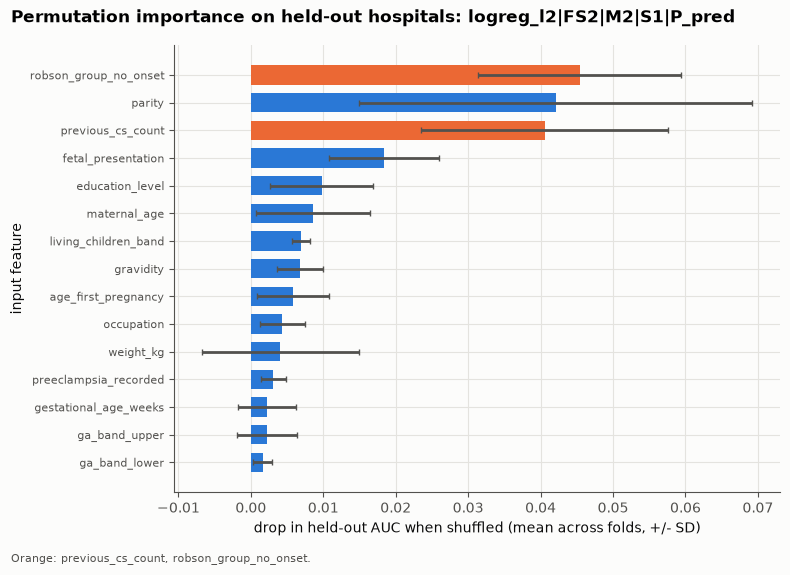

In [42]:
if fitted:
    permutation = explain.permutation_importances(
        fitted, x_sel, y_sel, n_repeats=PERMUTATION_REPEATS, seed=SEED
    )
    show(
        figures.importance_bars(
            permutation,
            "mean",
            f"Permutation importance on held-out hospitals: {chosen['config']}",
            "drop in held-out AUC when shuffled (mean across folds, +/- SD)",
            error="sd",
            highlight=explain.ROBSON_RECOVERY_FEATURES,
        )
    )

shap.PermutationExplainer: 500 held-out rows at most, 223 s


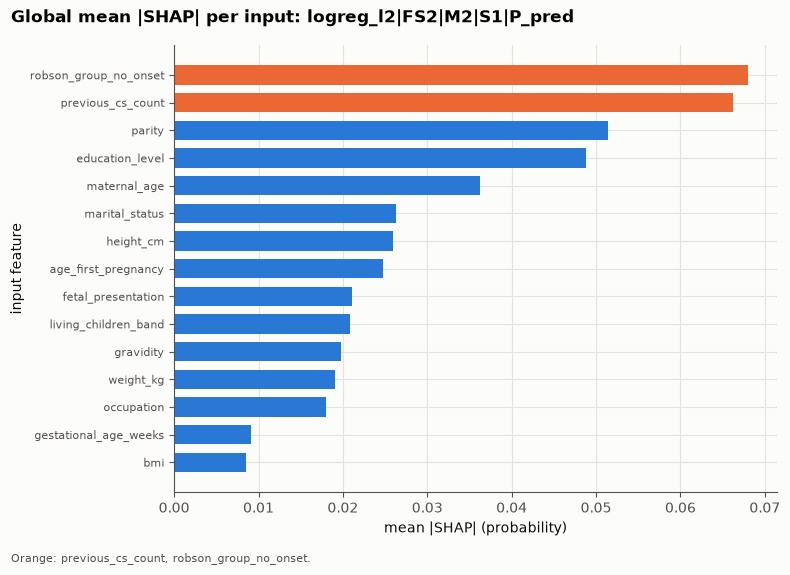

,top 3,Robson feature found,check
SHAP,"robson_group_no_onset, previous_cs_count, parity","previous_cs_count, robson_group_no_onset",passed
permutation,"robson_group_no_onset, parity, previous_cs_count","previous_cs_count, robson_group_no_onset",passed


In [43]:
if fitted:
    started = time.time()
    shap_table, shap_method = explain.shap_importance(
        fitted,
        x_sel,
        str(chosen["family"]),
        max_rows=SHAP_ROWS,
        background=SHAP_BACKGROUND,
        seed=SEED,
    )
    print(f"{shap_method}: {SHAP_ROWS} held-out rows at most, {time.time() - started:.0f} s")
    show(
        figures.importance_bars(
            shap_table,
            "mean_abs_shap",
            f"Global mean |SHAP| per input: {chosen['config']}",
            "mean |SHAP| (" + ("log-odds" if chosen["family"] == "tree" else "probability") + ")",
            highlight=explain.ROBSON_RECOVERY_FEATURES,
        )
    )
    recovery = {
        "SHAP": explain.robson_recovery(shap_table["mean_abs_shap"]),
        "permutation": explain.robson_recovery(permutation["mean"]),
    }
    display(
        pd.DataFrame(
            {
                name: {
                    "top 3": ", ".join(check.top),
                    "Robson feature found": ", ".join(check.found) or "none",
                    "check": "passed" if check.passed else "FAILED: open a leakage investigation",
                }
                for name, check in recovery.items()
            }
        ).T
    )

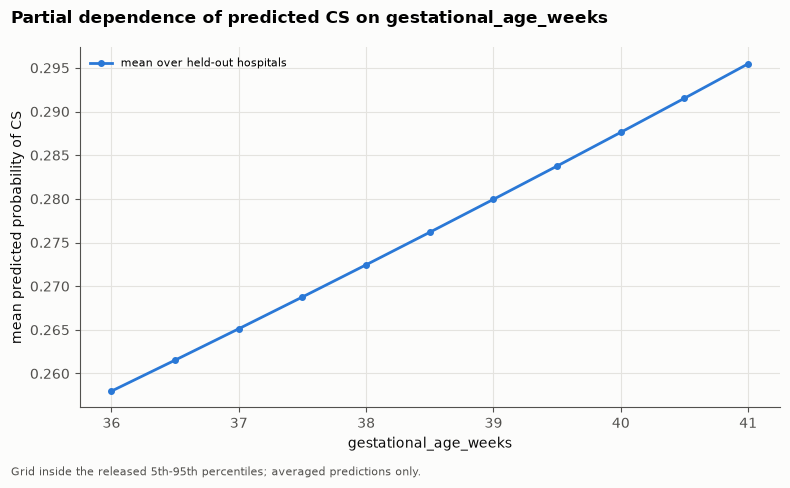

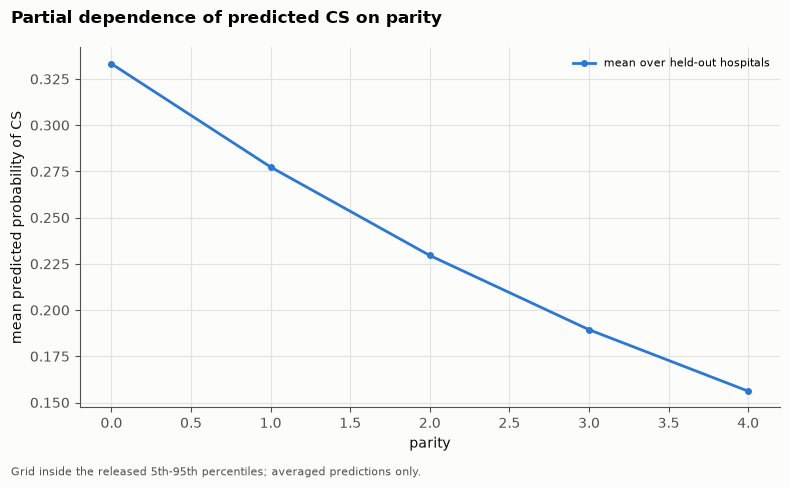

In [44]:
if fitted:
    pdp_curves = {}
    for feature, step in (("gestational_age_weeks", 0.5), ("parity", 1.0)):
        if feature not in x_sel.columns:
            print(f"{feature} is not an input of the selected configuration")
            continue
        grid_values = explain.pdp_grid(x_sel[feature], step=step)
        if len(grid_values) < 2:
            print(f"{feature}: too few values for a partial-dependence grid")
            continue
        pdp_curves[feature] = explain.partial_dependence(
            fitted, x_sel, feature, grid_values, seed=SEED
        )
    for feature, curve in pdp_curves.items():
        show(
            figures.line_curves(
                {"mean over held-out hospitals": curve},
                "value",
                "mean",
                f"Partial dependence of predicted CS on {feature}",
                feature,
                "mean predicted probability of CS",
                note="Grid inside the released 5th-95th percentiles; averaged predictions only.",
            )
        )

In [45]:
if selection.selected is not None and selection.baseline is not None:
    comparison_groups = explain.subgroup_comparison(
        run_artifact_table(TRACKING_URI, chosen["run_id"], "subgroups.csv"),
        run_artifact_table(TRACKING_URI, selection.baseline["run_id"], "subgroups.csv"),
        labels=(f"selected AUC ({chosen['model']})", "B1 AUC"),
    )
    display(Markdown("**AUC within each onset-free Robson group (pooled S1 out-of-fold)**"))
    display(comparison_groups)

**AUC within each onset-free Robson group (pooled S1 out-of-fold)**

,selected AUC (logreg_l2),B1 AUC
robson_group_no_onset,,
10,0.76,0.378
1_2,0.523,0.462
3_4,0.568,0.509
5,0.489,0.291
8,insufficient,insufficient
partial,0.843,0.43


## 14. Deployment variant and robustness (Phase F)

Four questions beyond the S1 leave-one-hospital-out evaluation already shown:

1. **Deployment-variant decision (spec §13.4):** does adding `facility_id` (the deploy variant) lower the selected specification's internal S3 log loss enough to use it for the single deployment fit?
2. **Temporal validation (S4):** how does the selected model perform on a held-out later period, against B1?
3. **Internal (S3) vs LOHO (S1) vs temporal (S4):** how does discrimination and calibration of the selected specification compare across all three evaluation designs?
4. **Sensitivity:** does the pre-v1.3 onset-coded population inflate discrimination through outcome leakage, relative to v1.3's `P_pred`?

A final cell reads the deployment artefact's own provenance summary. Every output below is an aggregate over the **current population version** (`POPULATION_VERSION`): no row, no identifier. In real mode, the S3/S4/sensitivity runs are read from `mlruns/`, produced outside this notebook by `robson-ml run configs/experiments/phase_f.yaml` and `configs/experiments/sensitivity_onset_coded.yaml`; the deployment artefact is produced by `robson-ml fit-deploy configs/deployment.yaml`. Synthetic mode has no such run, so the same tiny grid (and a demonstration deployment fit) is executed live in the next cell, at the same scale as section 9.

In [46]:
# Phase F execution (spec §13.4, §11.1 S3/S4). Real mode reads these runs from
# mlruns/ (see the section intro above). Synthetic mode has none of them yet, so the same
# tiny grid used in section 9 (SYNTHETIC_TRIALS trials, SYNTHETIC_BOOT bootstrap draws) is
# extended here: S3 for each non-baseline model's base and deploy feature set, S4 for every
# model (B1 included, as the S4 comparator), and a couple of onset-coded S1 runs (sensitivity
# population, kept small).
if MODE == "synthetic":
    non_baseline = [c for c in SYNTHETIC_GRID if c.model != "B1"]
    s3_grid = [
        ExperimentConfig(
            c.model, fs, c.missing_strategy, "S3", "P_pred", SYNTHETIC_TRIALS, SEED,
            SYNTHETIC_BOOT,
        )
        for c in non_baseline
        for fs in (c.feature_set, deploy_variant(c.feature_set))
    ]
    s4_grid = [
        ExperimentConfig(
            c.model, c.feature_set, c.missing_strategy, "S4", "P_pred", SYNTHETIC_TRIALS,
            SEED, SYNTHETIC_BOOT,
        )
        for c in SYNTHETIC_GRID
    ]
    onset_grid = [
        ExperimentConfig(
            c.model, c.feature_set, c.missing_strategy, "S1", "P_pred_onset_coded",
            SYNTHETIC_TRIALS, SEED, SYNTHETIC_BOOT,
        )
        for c in SYNTHETIC_GRID
        if c.model in ("B1", "logreg_l2")  # a couple of runs, kept small
    ]
    data_onset = build_model_data(classified, registry, raw_features, "P_pred_onset_coded")
    started = time.time()
    for phase_f_config in (*s3_grid, *s4_grid):
        run_experiment(phase_f_config, data, ctx)
    for phase_f_config in onset_grid:
        run_experiment(phase_f_config, data_onset, ctx)
    n_extra = len(s3_grid) + len(s4_grid) + len(onset_grid)
    print(f"{n_extra} additional synthetic configurations (S3/S4/onset-coded) in "
          f"{time.time() - started:.0f} s")

runs = load_runs(TRACKING_URI)  # refresh: the loop above may have logged more runs

### 14.1 Deployment-variant decision (spec §13.4)

`facility_id` is allowed as a feature only under S3 (internal evaluation) and in the S5 deployment fit, never under S1/S2/S4: the deploy variant is chosen for deployment only when its S3 mean log loss is lower than the base feature set's.

In [47]:
facility_decision = None
deploy_result = None
if selection.selected is None:
    print("no configuration selected: the deployment-variant decision is not available")
else:
    chosen = selection.selected
    try:
        facility_decision = deploy.deployment_feature_choice(
            TRACKING_URI,
            model=str(chosen["model"]),
            feature_set=str(chosen["feature_set"]),
            missing_strategy=str(chosen["missing_strategy"]),
            population=str(chosen["population"]),
        )
    except LookupError as exc:
        print(f"deployment-variant decision not available in this mode: {exc}")

    if facility_decision is not None:
        print(facility_decision["rule"])
        losses = pd.DataFrame(
            {
                "S3 mean log loss": {
                    facility_decision["feature_set"]: facility_decision["s3_mean_log_loss"],
                    facility_decision["deploy_feature_set"]: facility_decision[
                        "s3_mean_log_loss_deploy"
                    ],
                }
            }
        )
        display(losses.round(4))
        print(
            f"choice: {facility_decision['chosen_feature_set']} "
            f"(use_facility={facility_decision['use_facility']})"
        )

    # Synthetic mode: fit the S5 deployment model live (small demonstration scale) so the
    # facility-contribution chart and the artefact summary below have something to read.
    # Real mode reads the artefact `robson-ml fit-deploy` already wrote to artefacts/.
    if MODE == "synthetic" and facility_decision is not None:
        deploy_config = deploy.DeploymentConfig(
            model=str(chosen["model"]),
            feature_set=str(chosen["feature_set"]),
            use_facility=bool(facility_decision["use_facility"]),
            missing_strategy=str(chosen["missing_strategy"]),
            population=str(chosen["population"]),
            seed=SEED,
            n_trials=SYNTHETIC_TRIALS,
            version_label="phase-f-demo",
        )
        provenance = deploy.Provenance(
            tracking_uri=TRACKING_URI,
            data_hash=file_sha256(CLASSIFIED_PATH),
            features_yaml_hash=registry.sha256,
            git_commit=git_commit(REPO),
            selection_rule_commit=rule_commit,
        )
        deploy_result = deploy.fit_deployment(
            deploy_config,
            data,
            provenance,
            PROJECT / "artefacts",
            deploy_config.use_facility,
            facility_decision,
        )

spec §13.4: facility used only if the deploy variant's S3 mean log loss is lower


,S3 mean log loss
FS2,0.4704
FS2_deploy,0.4665


choice: FS2_deploy (use_facility=True)


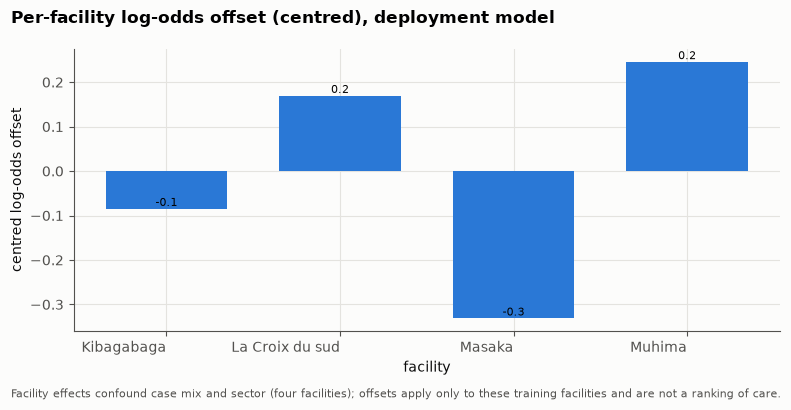

In [48]:
facility_table = None
if MODE == "real":
    facility_csv = REPORTS / "interpretation" / "facility_contribution.csv"
    if facility_csv.exists():
        facility_table = pd.read_csv(facility_csv)
elif deploy_result is not None and "facility_contribution" in deploy_result.summary:
    facility_table = pd.DataFrame(deploy_result.summary["facility_contribution"])

if facility_table is not None:
    show(
        figures.bar_chart(
            facility_table["facility_id"].astype(str).tolist(),
            facility_table["centred"].tolist(),
            "Per-facility log-odds offset (centred), deployment model",
            "facility",
            "centred log-odds offset",
            note=(
                "Facility effects confound case mix and sector (four facilities); offsets "
                "apply only to these training facilities and are not a ranking of care."
            ),
        )
    )
else:
    print("facility contribution: not available in this mode (facility not used for "
          "deployment, or no report found)")

### 14.2 Temporal validation (S4)

The selected specification and B1, trained on admissions up to end-January 2024 and evaluated on the following months (a single temporal fold, never a hospital held out).

In [49]:
if selection.selected is None:
    print("no configuration selected: temporal validation is not available")
else:
    chosen = selection.selected
    s4 = runs[(runs["split"] == "S4") & (runs["population"] == "P_pred")]
    selected_s4 = s4[
        (s4["model"] == chosen["model"])
        & (s4["feature_set"] == chosen["feature_set"])
        & (s4["missing_strategy"] == chosen["missing_strategy"])
    ]
    b1_s4 = s4[s4["model"] == "B1"]
    metric_cols = ["mean_auc", "mean_calibration_slope", "mean_calibration_in_the_large"]
    rows = {}
    if len(selected_s4):
        rows[str(chosen["config"])] = selected_s4[metric_cols].iloc[0]
    if len(b1_s4):
        rows["B1"] = b1_s4[metric_cols].iloc[0]
    if rows:
        s4_table = pd.DataFrame(rows).T
        s4_table.columns = ["AUC", "calibration slope", "calibration-in-the-large"]
        display(Markdown("**Temporal validation (S4): train up to end-January 2024, test after**"))
        display(s4_table.round(3))
    else:
        print("no S4 run of the selected specification or B1 is available in this mode")
    if len(selected_s4) and len(b1_s4):
        selected_auc = float(selected_s4["mean_auc"].iloc[0])
        b1_auc = float(b1_s4["mean_auc"].iloc[0])
        slope = float(selected_s4["mean_calibration_slope"].iloc[0])
        if selected_auc > b1_auc:
            comparison = "higher than"
        elif abs(selected_auc - b1_auc) < 1e-9:
            comparison = "about the same as"
        else:
            comparison = "lower than"
        if 0.8 <= slope <= 1.2:
            calib = "close to 1 (well calibrated)"
        elif slope > 1.2:
            calib = "above 1 (under-confident: predictions vary less than the outcome does)"
        else:
            calib = "below 1 (over-confident: predictions vary more than the outcome does)"
        print(
            f"On the held-out later period, the selected model's AUC ({selected_auc:.3f}) is "
            f"{comparison} B1's ({b1_auc:.3f}); its calibration slope ({slope:.2f}) is {calib}."
        )

**Temporal validation (S4): train up to end-January 2024, test after**

,AUC,calibration slope,calibration-in-the-large
logreg_l2|FS2|M2|S1|P_pred,0.772,1.148,-0.415
B1,0.725,1.239,-0.013


On the held-out later period, the selected model's AUC (0.772) is higher than B1's (0.725); its calibration slope (1.15) is close to 1 (well calibrated).


### 14.3 Internal (S3) vs leave-one-hospital-out (S1) vs temporal (S4)

The selected specification's discrimination and calibration side by side across the three evaluation designs: S3 is ordinary internal cross-validation (optimistic), S1 holds out a whole hospital in turn, and S4 holds out a later time period.

**logreg_l2|FS2|M2|S1|P_pred: discrimination and calibration by split**

,mean_auc,mean_calibration_slope
split,,
S3,0.763,1.000
S1,0.752,0.987
S4,0.772,1.148


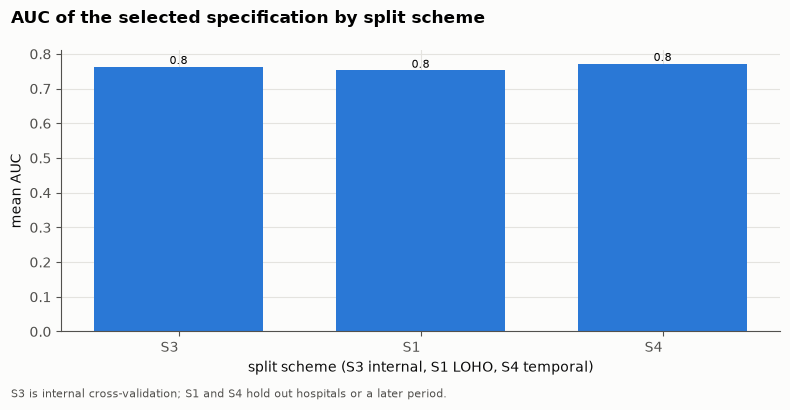

In [50]:
if selection.selected is None:
    print("no configuration selected: nothing to compare across splits")
else:
    chosen = selection.selected
    same_spec = (
        (runs["model"] == chosen["model"])
        & (runs["feature_set"] == chosen["feature_set"])
        & (runs["missing_strategy"] == chosen["missing_strategy"])
        & (runs["population"] == "P_pred")
        & (runs["split"].isin(["S1", "S3", "S4"]))
    )
    by_split = runs[same_spec].set_index("split")[["mean_auc", "mean_calibration_slope"]]
    by_split = by_split.reindex(["S3", "S1", "S4"]).dropna(how="all")
    if len(by_split):
        display(Markdown(f"**{chosen['config']}: discrimination and calibration by split**"))
        display(by_split.round(3))
        show(
            figures.bar_chart(
                by_split.index.tolist(),
                by_split["mean_auc"].tolist(),
                "AUC of the selected specification by split scheme",
                "split scheme (S3 internal, S1 LOHO, S4 temporal)",
                "mean AUC",
                note="S3 is internal cross-validation; S1 and S4 hold out hospitals or a later period.",
            )
        )
    else:
        print("no S1/S3/S4 runs of the selected specification are available in this mode")

### 14.4 Sensitivity: onset-coded population vs v1.3 `P_pred`

The same models, run on the pre-v1.3 onset-coded population `P_pred_onset_coded` (`onset_of_labour` restored, spec v1.3 item 4) instead of `P_pred`, under S1.

In [51]:
key_cols = ["model", "feature_set", "missing_strategy"]
onset = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred_onset_coded")]
pred = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred")]
sensitivity = onset.merge(pred, on=key_cols, suffixes=(" (onset-coded)", " (P_pred)"))
if len(sensitivity):
    sensitivity = sensitivity.assign(
        config=lambda d: d[key_cols].agg("|".join, axis=1)
    ).set_index("config")
    columns = [
        "mean_auc (P_pred)",
        "mean_auc (onset-coded)",
        "mean_calibration_slope (P_pred)",
        "mean_calibration_slope (onset-coded)",
    ]
    display(Markdown("**AUC and calibration slope: v1.3 `P_pred` vs the onset-coded sensitivity population**"))
    display(sensitivity[columns].round(3))
else:
    print("no matching P_pred / P_pred_onset_coded S1 runs are available in this mode")

**AUC and calibration slope: v1.3 `P_pred` vs the onset-coded sensitivity population**

,mean_auc (P_pred),mean_auc (onset-coded),mean_calibration_slope (P_pred),mean_calibration_slope (onset-coded)
config,,,,
logreg_l2|FS4|M1,0.751,0.749,0.984,0.723
logreg_l2|FS4|M2,0.752,0.757,0.984,0.717
mlp|FS4|M1,0.742,0.773,0.914,0.613
mlp|FS4|M2,0.753,0.773,0.957,0.679
xgboost|FS4|M0,0.748,0.791,0.954,0.835
xgboost|FS4|M1,0.745,0.772,0.945,0.717
xgboost|FS4|M2,0.750,0.784,0.980,0.814


Onset of labour is often coded only once a caesarean has already happened (spec v1.3 item 4), so a model that reads onset, or the onset-based Robson group restored only for this legacy population, is partly reading the outcome itself. When the onset-coded population's AUC is **higher** than v1.3 `P_pred`'s for the same model while its calibration slope **collapses toward zero** (predictions cluster near a fixed value instead of spreading with the true risk), that combination is the signature of **outcome leakage**, not genuinely better discrimination: the model has learned a proxy for "a caesarean was performed" rather than a readiness signal available before delivery. This is why onset is excluded from every model built on `P_pred`, and `P_pred_onset_coded` is kept only as a sensitivity check, never as a candidate for selection.

### 14.5 Deployment artefact summary

Provenance and aggregate facts read from the deployment fit's own `fit_summary.json` (spec §11.1 S5, §13.1); no row and no identifier.

In [52]:
summary = None
if MODE == "real":
    deployment_config_path = PROJECT / "configs" / "deployment.yaml"
    if deployment_config_path.exists():
        try:
            dcfg = deploy.load_deployment_config(deployment_config_path)
            summary_path = REPO / "artefacts" / dcfg.version_label / deploy.SUMMARY_FILE
            if summary_path.exists():
                summary = json.loads(summary_path.read_text(encoding="utf-8"))
            else:
                print(
                    "deployment artefact summary not available in this mode "
                    f"({summary_path.name} not found)"
                )
        except ValueError as exc:
            print(f"deployment config could not be read: {exc}")
    else:
        print("deployment artefact summary not available in this mode (no deployment config)")
elif deploy_result is not None:
    summary = deploy_result.summary
else:
    print("deployment artefact summary not available in this mode")

if summary is not None:
    fields = {
        "version label": summary["version_label"],
        "algorithm": summary["algorithm"],
        "feature set": summary["feature_set"],
        "calibration method": summary["calibration"]["method"],
        "fit rows": summary["n_fit_rows"],
        "calibration rows": summary["n_calibration_rows"],
        "training window": (
            f"{summary['training_window_start']} to {summary['training_window_end']}"
        ),
    }
    display(pd.DataFrame({"value": fields}).rename_axis("field"))

,value
field,
version label,readiness-v1.0
algorithm,logreg_l2
feature set,FS2_deploy
calibration method,platt
fit rows,3412
calibration rows,853
training window,2023-11 to 2024-03


## 15. Limitations and next steps

**Data**

* **Onset contamination.** "Planned C-section" onset is often coded after the fact (96-99% of CS at
  two hospitals until early January 2024). Onset is excluded from every model, so the Robson feature
  merges groups 1+2 and 3+4. The onset-coded population is kept only as a sensitivity analysis. Robson
  audit tables still use onset, and groups 2/4 and 2a/2b/4a/4b carry a caveat.
* **Presentation recorded only as yes/no malpresentation.** Groups 6, 7 and 9 resolve only when the type
  is known, and the rest stay partial.
* **Gestational age.** The exact GA comes from free text for about two thirds of records; the rest have
  only a band. The 35-37-week band straddles the 37-week cut-off and cannot be resolved.
* **Under-recording.** Pre-eclampsia (about 1%) and gestational diabetes (about 0.1%) are severely
  under-recorded. A recorded "no" may be a true "yes". They are never prediction targets, and RQ2 is
  handled as a misclassification sensitivity analysis.
* **Plurality** comes from a general "multiple pregnancy" field. Rows sharing a patient identifier are
  kept and grouped by mother in every split.
* **CS with no recorded type** are kept in P_pred and counted; some may have been planned.

**Design**

* **Four facilities.** A leave-one-hospital-out mean over four sites is imprecise, and between-facility
  variation cannot be separated into random effects.
* **Sector confound.** Facility and public/private sector cannot be separated.
* **S2** recalibrates on each hospital's first 150 admissions and evaluates the rest, which are not the
  same rows as S1. **S4** uses a short test period.
* **P_pred excludes planned CS**, which deployment does not score. Emergency CS typed after the fact are
  included; the exclusions are reported (§6).

**Next steps:** section 14 (Phase F) has now run S5 (deployment fit) for the selected
specification's base feature set and its deploy variant (currently FS2 and FS2_deploy per
DECISIONS.md; the pair follows whatever the pre-registered rule selects) and S4; package the
artefact with its manifest and contract test; carry out the case-mix and missingness analyses
(RQ1/RQ2); and run the P1 zoo. A real-data execution of this notebook is saved under
`reports/notebooks/`, which is never committed.